<a href="https://colab.research.google.com/github/Nipuni7/Nipuni7/blob/main/Lab03_Tiny_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import torch
import sys

print("Python Version:", sys.version.split()[0])
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("Device:", "cuda")
else:
    print("Device:", "cpu")


Python Version: 3.13.15
PyTorch Version: 2.11.0+cu130
CUDA Available: True
GPU Name: Tesla T4
Device: cuda



# PUSL 3205 – Large Language Models and Generative AI

## Laboratory 03: Developing a Tiny Transformer Language Model

**Degree Programme:** BSc (Hons) Data Science  
**Practical Date:** 10 October 2026  
**Framework:** PyTorch  
**Dataset:** TinyStories (Hugging Face)  
**Platform:** Google Colab (Tesla T4 GPU)

---

### 1. Introduction

This laboratory focuses on developing a small Transformer-based language model capable of predicting the next token and generating short stories.

The model will be trained using the TinyStories dataset. The implementation explores fundamental Transformer mechanisms, including token embeddings, positional embeddings, masked multi-head self-attention, feed-forward networks, residual connections, and layer normalization.

### 2. Learning Objectives

- Load and explore the TinyStories dataset.
- Preprocess and tokenize story text.
- Prepare input and target sequences.
- Implement a causal Transformer language model.
- Train the model using cross-entropy loss.
- Monitor training and validation loss.
- Evaluate performance using perplexity.
- Generate new stories from text prompts.
- Compare different model configurations.
- Save the trained model for future use.

### 3. Development Environment

| Component | Configuration |
|---|---|
| Platform | Google Colab |
| Python | 3.13.15 |
| PyTorch | 2.11.0+cu130 |
| GPU | NVIDIA Tesla T4 |
| CUDA | Available |
| Dataset | roneneldan/TinyStories |

---




## 4. Task 1 – Loading and Exploring the TinyStories Dataset

### 4.1 Installing the Required Library

The Hugging Face Datasets library provides access to datasets for machine learning and natural language processing.

In this task, the TinyStories dataset will be loaded and explored to understand its structure and text characteristics.


In [2]:

%pip install -q datasets



### 4.2 Loading the TinyStories Dataset

The TinyStories dataset contains short, simple English stories designed for language model research.

For this experiment, a subset of 2,000 training stories and 200 validation stories is selected to reduce computational requirements and enable faster experimentation.

The Hugging Face Datasets library is used to load the data directly into Google Colab.


In [3]:

from datasets import load_dataset

train_dataset = load_dataset(
    "roneneldan/TinyStories",
    split="train[:2000]"
)

val_dataset = load_dataset(
    "roneneldan/TinyStories",
    split="validation[:200]"
)

print("Training stories:", len(train_dataset))
print("Validation stories:", len(val_dataset))
print("Dataset columns:", train_dataset.column_names)


README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/train-00001-of-00004-5852b56a2bd28f(…): reconstructing file:   0%|          |  0.00B /  248MB            

data/train-00001-of-00004-5852b56a2bd28f(…): downloading bytes:           |  0.00B            

...

data/validation-00000-of-00001-869c898b5(…): reconstructing file:   0%|          |  0.00B / 9.99MB            

data/validation-00000-of-00001-869c898b5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Training stories: 2000
Validation stories: 200
Dataset columns: ['text']



### 4.3 Exploring Sample Stories

**Objective:** To examine the content, structure, and character lengths of the TinyStories dataset.

**Method:** Display the first three training stories and calculate the number of characters and words in each story.

This exploration helps us understand the dataset before tokenization and sequence preparation.


In [4]:

# Display sample stories and their lengths

for i in range(3):
    story = train_dataset[i]["text"]

    print(f"\n{'=' * 60}")
    print(f"STORY {i + 1}")
    print(f"{'=' * 60}")

    print(story)

    print("\n--- Story Statistics ---")
    print("Characters:", len(story))
    print("Words:", len(story.split()))



STORY 1
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.

--- Story Statistics ---
Characters: 701
Words: 134

STORY 2
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the par


### 4.4 Observations and Analysis

**Dataset Exploration Results**

| Story | Characters | Words |
|---|---:|---:|
| Story 1 | 701 | 134 |
| Story 2 | 705 | 142 |
| Story 3 | 822 | 168 |
| **Average** | **742.7** | **148** |

**Observations:**

1. The sampled stories use simple English vocabulary and relatively short sentences.
2. The stories contain recognizable narrative structures, including introductions, events, and conclusions.
3. The sample character lengths range from 701 to 822 characters.
4. The sample word counts range from 134 to 168 words.
5. The stories contain punctuation, dialogue, and paragraph breaks, which are relevant to language modeling.

**Analysis:**

The TinyStories dataset is suitable for experimenting with a small Transformer language model because the sampled stories exhibit coherent narrative patterns and relatively simple vocabulary.

Character-level tokenization can preserve punctuation, spaces, and capitalization while avoiding the need for a large word-level vocabulary.

However, character-level sequences can become relatively long, increasing the computational cost of self-attention.

These findings are based on the three inspected stories and do not necessarily represent the entire dataset.

**Conclusion:**

The initial exploration confirms that the selected dataset can be used to proceed with text preprocessing, tokenization, and next-token prediction experiments.



## 5. Task 2 – Text Preprocessing and Tokenization

### 5.1 Character-Level Tokenization

**Objective:** To convert raw story text into numerical tokens that can be processed by a Transformer language model.

**Theory:**

Tokenization is the process of dividing text into smaller units called tokens.

In character-level tokenization, each unique character is treated as an individual token.

For example, the text "cat" can be represented as three character tokens: "c", "a", and "t".

A vocabulary is constructed by identifying the unique characters in the selected training corpus.

Each character is assigned a unique integer ID using a character-to-index mapping.

An inverse mapping is also created to convert generated token IDs back into readable text.

**Advantages:**
- Simple to implement.
- Handles individual characters without word-level out-of-vocabulary issues.
- Preserves punctuation, capitalization, and spaces.

**Limitations:**
- Produces longer token sequences.
- Requires the model to learn word structure from individual characters.
- Longer sequences increase attention computation.

---


In [5]:

# Step 2.1.2: Build Character-Level Vocabulary

# Combine all selected training stories
train_text = "\n".join(train_dataset["text"])

# Extract and sort unique characters
chars = sorted(set(train_text))

# Calculate vocabulary size
vocab_size = len(chars)

# Create character-to-index mapping
stoi = {ch: i for i, ch in enumerate(chars)}

# Create index-to-character mapping
itos = {i: ch for i, ch in enumerate(chars)}

# Display vocabulary information
print("Total Training Characters:", len(train_text))
print("Vocabulary Size:", vocab_size)
print("Unique Characters:", repr("".join(chars)))

print("\nFirst 10 Character Mappings:")
for ch in chars[:10]:
    print(f"{repr(ch):8} -> {stoi[ch]}")


Total Training Characters: 1702919
Vocabulary Size: 80
Unique Characters: '\n !"$\',-.01234568:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz¦âœ˜“”€™'

First 10 Character Mappings:
'\n'     -> 0
' '      -> 1
'!'      -> 2
'"'      -> 3
'$'      -> 4
"'"      -> 5
','      -> 6
'-'      -> 7
'.'      -> 8
'0'      -> 9



### 5.2 Text Encoding and Decoding

**Objective:** To implement functions that convert text into numerical token IDs and reconstruct text from those IDs.

**Encoding:** Converts each character into its corresponding integer ID using the character-to-index mapping (`stoi`).

**Decoding:** Converts a sequence of integer IDs back into readable text using the index-to-character mapping (`itos`).

These operations are essential because Transformer models process numerical representations rather than raw text.


In [6]:

# Step 2.1.3: Character Encoding and Decoding

def encode(text):
    return [stoi[ch] for ch in text]

def decode(token_ids):
    return "".join(itos[i] for i in token_ids)

# Test the tokenizer
sample_text = "Once upon a time"

encoded_text = encode(sample_text)
decoded_text = decode(encoded_text)

print("Original Text:", sample_text)
print("Encoded Tokens:", encoded_text)
print("Decoded Text:", decoded_text)
print("Encoding Successful:", sample_text == decoded_text)


Original Text: Once upon a time
Encoded Tokens: [34, 59, 48, 50, 1, 66, 61, 60, 59, 1, 46, 1, 65, 54, 58, 50]
Decoded Text: Once upon a time
Encoding Successful: True



### 5.3 Validation Vocabulary Compatibility

**Objective:** To identify whether the validation dataset contains characters that are absent from the training vocabulary.

The character vocabulary is constructed using training data only to avoid incorporating validation information into the tokenizer.

Before encoding validation stories, the unique characters in the validation corpus are compared against the training vocabulary.

This check helps identify potential out-of-vocabulary characters and determine whether additional handling is required.


In [7]:

# Step 2.1.4: Check for unseen validation characters

val_text = "\n".join(val_dataset["text"])

train_chars = set(chars)
val_chars = set(val_text)

unknown_chars = sorted(val_chars - train_chars)

print("Training Vocabulary Size:", vocab_size)
print("Validation Characters:", len(val_chars))
print("Unknown Validation Characters:", len(unknown_chars))
print("Unknown Characters:", repr("".join(unknown_chars)))

if len(unknown_chars) == 0:
    print("Validation vocabulary compatibility: PASSED")
else:
    print("Validation vocabulary compatibility: NEEDS HANDLING")


Training Vocabulary Size: 80
Validation Characters: 62
Unknown Validation Characters: 0
Unknown Characters: ''
Validation vocabulary compatibility: PASSED



### 5.4 Converting Text into PyTorch Tensors

**Objective:** To convert the training and validation corpora into numerical tensors for language model training.

**Method:**

1. Encode the training and validation text using the character-level tokenizer.
2. Convert the resulting token IDs into PyTorch tensors.
3. Use the `torch.long` data type because token IDs are integer indices used by embedding layers.
4. Keep training and validation tensors separate to support unbiased model evaluation.

The resulting tensors will be used to construct input-target sequences for next-token prediction.


In [8]:

# Step 2.2: Convert text into PyTorch tensors

import torch

train_data = torch.tensor(
    encode(train_text),
    dtype=torch.long
)

val_data = torch.tensor(
    encode(val_text),
    dtype=torch.long
)

print("Training Tensor Shape:", train_data.shape)
print("Validation Tensor Shape:", val_data.shape)

print("Training Data Type:", train_data.dtype)
print("Validation Data Type:", val_data.dtype)

print("\nFirst 20 Training Token IDs:")
print(train_data[:20])

print("\nFirst 20 Validation Token IDs:")
print(val_data[:20])


Training Tensor Shape: torch.Size([1702919])
Validation Tensor Shape: torch.Size([155395])
Training Data Type: torch.int64
Validation Data Type: torch.int64

First 20 Training Token IDs:
tensor([34, 59, 50,  1, 49, 46, 70,  6,  1, 46,  1, 57, 54, 65, 65, 57, 50,  1,
        52, 54])

First 20 Validation Token IDs:
tensor([38, 61, 60, 65,  8,  1, 38, 61, 60, 65,  1, 64, 46, 68,  1, 65, 53, 50,
         1, 64])



## 6. Task 3 – Input and Target Sequence Preparation

### 6.1 Next-Token Prediction

**Objective:** To prepare input and target sequences for autoregressive language modeling.

**Theory:**

A causal Transformer language model learns to predict the next token based on previously observed tokens.

For a character-level language model, the input consists of a sequence of character IDs, while the target consists of the same sequence shifted forward by one character.

**Example:**

Input (X):  `Once`

Target (Y): `nce `

At each position, the model predicts the next character using only the current and previous input characters.

A causal attention mask will later prevent the model from accessing future tokens during training.

This process is known as **next-token prediction** and is the fundamental training objective of autoregressive language models.


In [9]:

# Step 3.2: Create input-target training batches

batch_size = 32
block_size = 128

device = "cuda" if torch.cuda.is_available() else "cpu"

def get_batch(split):
    # Select training or validation data
    data = train_data if split == "train" else val_data

    # Random starting positions
    ix = torch.randint(
        len(data) - block_size,
        (batch_size,)
    )

    # Input sequences
    x = torch.stack([
        data[i:i + block_size]
        for i in ix
    ])

    # Target sequences shifted by one token
    y = torch.stack([
        data[i + 1:i + block_size + 1]
        for i in ix
    ])

    return x.to(device), y.to(device)


# Test the batch generator
X, Y = get_batch("train")

print("Device:", device)
print("Input Shape:", X.shape)
print("Target Shape:", Y.shape)

print("\nFirst 20 Input Tokens:")
print(X[0, :20])

print("\nFirst 20 Target Tokens:")
print(Y[0, :20])

print("\nInput Text:")
print(repr(decode(X[0, :50].tolist())))

print("\nTarget Text:")
print(repr(decode(Y[0, :50].tolist())))

print("\nNext-Token Alignment Correct:",
      torch.equal(X[:, 1:], Y[:, :-1]))


Device: cuda
Input Shape: torch.Size([32, 128])
Target Shape: torch.Size([32, 128])

First 20 Input Tokens:
tensor([ 1, 53, 54, 64,  1, 65, 60, 70,  1, 64, 53, 60, 67, 50, 57,  1, 54, 59,
         1, 65], device='cuda:0')

First 20 Target Tokens:
tensor([53, 54, 64,  1, 65, 60, 70,  1, 64, 53, 60, 67, 50, 57,  1, 54, 59,  1,
        65, 53], device='cuda:0')

Input Text:
' his toy shovel in the sand.\nOnce upon a time, the'

Target Text:
'his toy shovel in the sand.\nOnce upon a time, ther'

Next-Token Alignment Correct: True



### 6.2 Batch Generation Results and Analysis

**Experimental Configuration**

| Parameter | Value |
|---|---|
| Batch Size | 32 |
| Context Length (Block Size) | 128 |
| Input Tensor Shape | (32, 128) |
| Target Tensor Shape | (32, 128) |
| Computation Device | CUDA GPU |
| Token Data Type | torch.int64 |

**Results:**

The batch generation function successfully produced input and target tensors with dimensions (32, 128).

Each batch contains 32 randomly selected sequences, with each sequence consisting of 128 character tokens.

The target sequences were constructed by shifting the input sequences forward by one character.

**Verification:**

The next-token alignment test returned `True`, confirming that each target token corresponds to the character immediately following its input token.

**Analysis:**

Random sampling provides different training sequences across iterations.

A context length of 128 allows the Transformer to learn dependencies within a window of 128 characters.

The tensors are transferred to the CUDA-enabled GPU to support accelerated model training.

**Conclusion:**

Input-target sequence preparation was completed successfully. The resulting batches are ready to be used for training a causal Transformer language model.



## 7. Task 4 – Transformer Model Architecture

### 7.1 Token and Positional Embeddings

**Objective:** To represent character tokens and their positions as dense numerical vectors.

**Token Embeddings:**

Token embeddings convert integer token IDs into trainable dense vectors.

Each character is represented by a vector of dimension `n_embd = 128`.

**Positional Embeddings:**

Transformers do not inherently represent token positions through their embedding layers.

Therefore, learnable positional embeddings are added to token embeddings to provide information about each character's position in the input sequence.

**Mathematical Representation:**

Input Representation = Token Embedding + Positional Embedding

**Experimental Configuration:**

| Parameter | Value |
|---|---|
| Vocabulary Size | 80 |
| Embedding Dimension | 128 |
| Context Length | 128 |
| Batch Size | 32 |

The combined embeddings will be passed into the Transformer attention layers.


In [10]:

# Step 4.1: Token and Positional Embeddings

import torch
import torch.nn as nn

# Model configuration
n_embd = 128

# Token embedding layer
token_embedding = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=n_embd
).to(device)

# Positional embedding layer
position_embedding = nn.Embedding(
    num_embeddings=block_size,
    embedding_dim=n_embd
).to(device)

# Use the training batch created earlier
B, T = X.shape

# Generate position indices
positions = torch.arange(T, device=device)

# Compute embeddings
token_emb = token_embedding(X)
pos_emb = position_embedding(positions)

# Combine token and positional embeddings
combined_emb = token_emb + pos_emb

# Display tensor dimensions
print("Input Shape:", X.shape)
print("Token Embedding Shape:", token_emb.shape)
print("Position Embedding Shape:", pos_emb.shape)
print("Combined Embedding Shape:", combined_emb.shape)

print("\nEmbedding Dimension:", n_embd)
print("Device:", combined_emb.device)


Input Shape: torch.Size([32, 128])
Token Embedding Shape: torch.Size([32, 128, 128])
Position Embedding Shape: torch.Size([128, 128])
Combined Embedding Shape: torch.Size([32, 128, 128])

Embedding Dimension: 128
Device: cuda:0



### 7.2 Masked Self-Attention

**Objective:** To implement a causal self-attention head that prevents information leakage from future tokens.

**Theory:**

Self-attention enables each token to incorporate information from other relevant tokens in a sequence.

The input embeddings are projected into three representations:

- **Query (Q):** Represents the information a token is looking for.
- **Key (K):** Represents the information available for matching.
- **Value (V):** Contains the information to be aggregated.

Scaled dot-product attention is computed as:

Attention(Q, K, V) = softmax(QKᵀ / √dₖ + Mask)V

A causal mask prevents each position from attending to future positions.

This ensures that the Transformer follows the autoregressive next-token prediction objective.


In [11]:

# Step 4.2: Implement a Single Causal Self-Attention Head

import torch.nn.functional as F

class AttentionHead(nn.Module):
    def __init__(self, head_size):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # Lower-triangular causal attention mask
        self.register_buffer(
            "tril",
            torch.tril(torch.ones(block_size, block_size))
        )

    def forward(self, x):
        B, T, C = x.shape

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Scaled dot-product attention
        weights = q @ k.transpose(-2, -1)
        weights = weights * (k.shape[-1] ** -0.5)

        # Prevent attention to future positions
        weights = weights.masked_fill(
            self.tril[:T, :T] == 0,
            float("-inf")
        )

        weights = F.softmax(weights, dim=-1)

        # Weighted sum of value vectors
        output = weights @ v

        return output


# Test one attention head
head_size = 32

attention_head = AttentionHead(head_size).to(device)

attention_output = attention_head(combined_emb)

print("Input Shape:", combined_emb.shape)
print("Attention Output Shape:", attention_output.shape)
print("Device:", attention_output.device)

print(
    "Expected Shape Correct:",
    attention_output.shape == (32, 128, 32)
)


Input Shape: torch.Size([32, 128, 128])
Attention Output Shape: torch.Size([32, 128, 32])
Device: cuda:0
Expected Shape Correct: True



### 7.3 Multi-Head Self-Attention

**Objective:** To implement multi-head causal self-attention using four parallel attention heads.

**Theory:**

Multi-head attention enables a Transformer to learn different attention patterns through multiple independently parameterized attention heads.

Each attention head performs scaled dot-product attention using its own Query, Key, and Value projections.

The outputs of all attention heads are concatenated and passed through a learnable linear projection.

**Experimental Configuration:**

| Parameter | Value |
|---|---|
| Embedding Dimension | 128 |
| Number of Attention Heads | 4 |
| Dimension per Head | 32 |
| Concatenated Dimension | 128 |

**Mathematical Representation:**

MultiHead(Q, K, V) = Concat(head₁, head₂, head₃, head₄)Wₒ

Each head uses a causal mask to prevent access to future tokens.


In [12]:

# Step 4.3: Implement Multi-Head Self-Attention

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()

        # Create multiple independent attention heads
        self.heads = nn.ModuleList([
            AttentionHead(head_size)
            for _ in range(num_heads)
        ])

        # Project concatenated outputs
        self.proj = nn.Linear(
            num_heads * head_size,
            n_embd
        )

    def forward(self, x):
        # Run attention heads in parallel conceptually
        outputs = [head(x) for head in self.heads]

        # Concatenate head outputs
        concatenated = torch.cat(outputs, dim=-1)

        # Apply output projection
        return self.proj(concatenated)


# Test multi-head attention
n_head = 4
head_size = n_embd // n_head

multi_head_attention = MultiHeadAttention(
    n_head,
    head_size
).to(device)

multi_head_output = multi_head_attention(combined_emb)

print("Number of Attention Heads:", n_head)
print("Dimension per Head:", head_size)

print("Input Shape:", combined_emb.shape)
print("Multi-Head Output Shape:", multi_head_output.shape)
print("Device:", multi_head_output.device)

print(
    "Expected Shape Correct:",
    multi_head_output.shape == combined_emb.shape
)


Number of Attention Heads: 4
Dimension per Head: 32
Input Shape: torch.Size([32, 128, 128])
Multi-Head Output Shape: torch.Size([32, 128, 128])
Device: cuda:0
Expected Shape Correct: True



### 7.4 Position-Wise Feed-Forward Network

**Objective:** To implement a feed-forward neural network that transforms the token representations produced by the attention mechanism.

**Theory:**

A Transformer block contains a position-wise feed-forward neural network following the multi-head attention mechanism.

The feed-forward network applies the same fully connected transformations independently to each token position.

It consists of:

1. A linear layer that expands the embedding dimension.
2. A ReLU activation function that introduces non-linearity.
3. A second linear layer that projects the representation back to the original embedding dimension.

**Mathematical Representation:**

FFN(x) = Linear₂(ReLU(Linear₁(x)))

**Experimental Configuration:**

| Parameter | Value |
|---|---|
| Input Dimension | 128 |
| Hidden Dimension | 512 |
| Output Dimension | 128 |
| Activation Function | ReLU |

The feed-forward network enables the Transformer to learn more complex non-linear transformations of token representations.


In [13]:

# Step 4.4: Implement Feed-Forward Neural Network

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd)
        )

    def forward(self, x):
        return self.net(x)


# Test Feed-Forward Network
feed_forward = FeedForward(n_embd).to(device)

ffn_output = feed_forward(multi_head_output)

print("Input Shape:", multi_head_output.shape)
print("FFN Output Shape:", ffn_output.shape)
print("Hidden Dimension:", 4 * n_embd)
print("Device:", ffn_output.device)

print(
    "Expected Shape Correct:",
    ffn_output.shape == multi_head_output.shape
)


Input Shape: torch.Size([32, 128, 128])
FFN Output Shape: torch.Size([32, 128, 128])
Hidden Dimension: 512
Device: cuda:0
Expected Shape Correct: True



### 7.5 Transformer Block with Residual Connections and Layer Normalization

**Objective:** To combine masked multi-head self-attention and a feed-forward network into a complete Transformer block.

**Layer Normalization:**

Layer normalization normalizes token representations across their feature dimensions, helping stabilize neural network training.

**Residual Connections:**

Residual connections add the original input to the output of a sublayer, supporting gradient flow and helping preserve information across multiple layers.

**Architecture:**

This implementation uses a Pre-LayerNorm Transformer block.

1. Apply layer normalization before multi-head self-attention.
2. Add the attention output to the original input through a residual connection.
3. Apply a second layer normalization before the feed-forward network.
4. Add the feed-forward output through another residual connection.

**Mathematical Representation:**

x₁ = x + MultiHeadAttention(LayerNorm₁(x))

x₂ = x₁ + FeedForward(LayerNorm₂(x₁))

**Expected Output Shape:** (32, 128, 128)

This structure can be stacked to construct a deeper causal Transformer language model.


In [14]:

# Step 4.5: Complete Transformer Block

class TransformerBlock(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()

        assert n_embd % n_head == 0, (
            "Embedding dimension must be divisible by number of heads."
        )

        head_size = n_embd // n_head

        # Masked multi-head self-attention
        self.sa = MultiHeadAttention(n_head, head_size)

        # Feed-forward network
        self.ffwd = FeedForward(n_embd)

        # Layer normalization
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # Attention with residual connection
        x = x + self.sa(self.ln1(x))

        # Feed-forward with residual connection
        x = x + self.ffwd(self.ln2(x))

        return x


# Test Transformer Block
transformer_block = TransformerBlock(
    n_embd=n_embd,
    n_head=n_head
).to(device)

block_output = transformer_block(combined_emb)

print("Input Shape:", combined_emb.shape)
print("Transformer Block Output Shape:", block_output.shape)
print("Device:", block_output.device)

print(
    "Expected Shape Correct:",
    block_output.shape == combined_emb.shape
)


Input Shape: torch.Size([32, 128, 128])
Transformer Block Output Shape: torch.Size([32, 128, 128])
Device: cuda:0
Expected Shape Correct: True



### 7.6 Complete Tiny Transformer Language Model

**Objective:** To construct an autoregressive Transformer language model by integrating the previously implemented components.

**Architecture:**

1. Token embedding layer
2. Learnable positional embedding layer
3. Two stacked causal Transformer blocks
4. Final layer normalization
5. Linear language modeling head

**Model Configuration:**

| Hyperparameter | Value |
|---|---|
| Vocabulary Size | 80 |
| Embedding Dimension | 128 |
| Attention Heads | 4 |
| Transformer Layers | 2 |
| Context Length | 128 |
| Batch Size | 32 |
| Feed-Forward Hidden Dimension | 512 |

**Output:**

The model produces a vector of vocabulary logits for each token position.

These logits represent unnormalized prediction scores for the next character.

During training, cross-entropy loss will compare the predicted logits with the target token IDs.


In [15]:

# Step 4.6: Complete Tiny Transformer Language Model

class TinyTransformerLM(nn.Module):
    def __init__(self):
        super().__init__()

        # Token and positional embeddings
        self.token_embedding_table = nn.Embedding(
            vocab_size, n_embd
        )

        self.position_embedding_table = nn.Embedding(
            block_size, n_embd
        )

        # Stack Transformer blocks
        self.blocks = nn.Sequential(
            *[
                TransformerBlock(n_embd, n_head)
                for _ in range(2)
            ]
        )

        # Final normalization
        self.ln_f = nn.LayerNorm(n_embd)

        # Vocabulary prediction layer
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        if T > block_size:
            raise ValueError("Sequence exceeds block_size")

        # Embedding representations
        tok_emb = self.token_embedding_table(idx)

        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding_table(pos)

        x = tok_emb + pos_emb

        # Transformer layers
        x = self.blocks(x)

        # Final normalization and predictions
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None

        if targets is not None:
            B, T, C = logits.shape

            logits_flat = logits.reshape(B * T, C)
            targets_flat = targets.reshape(B * T)

            loss = F.cross_entropy(
                logits_flat, targets_flat
            )

        return logits, loss


# Initialize the model
model = TinyTransformerLM().to(device)

# Test forward pass
logits, loss = model(X, Y)

# Count trainable parameters
num_params = sum(
    p.numel() for p in model.parameters()
)

print("Model:", model.__class__.__name__)
print("Trainable Parameters:", f"{num_params:,}")
print("Input Shape:", X.shape)
print("Logits Shape:", logits.shape)
print("Initial Loss:", round(loss.item(), 4))
print("Device:", logits.device)

print(
    "Expected Logits Shape Correct:",
    logits.shape == (batch_size, block_size, vocab_size)
)


Model: TinyTransformerLM
Trainable Parameters: 432,976
Input Shape: torch.Size([32, 128])
Logits Shape: torch.Size([32, 128, 80])
Initial Loss: 4.5362
Device: cuda:0
Expected Logits Shape Correct: True



### 7.7 Model Architecture Results and Analysis

**Implementation Results**

| Metric | Result |
|---|---|
| Model Name | TinyTransformerLM |
| Trainable Parameters | 432,976 |
| Transformer Layers | 2 |
| Attention Heads per Layer | 4 |
| Embedding Dimension | 128 |
| Input Shape | (32, 128) |
| Output Logits Shape | (32, 128, 80) |
| Initial Cross-Entropy Loss | 4.5362 |
| Computation Device | CUDA GPU |

**Observations:**

The Transformer model was successfully initialized with 432,976 trainable parameters.

The forward pass produced logits with dimensions (32, 128, 80), corresponding to 32 sequences, 128 token positions per sequence, and 80 possible next-character predictions.

The initial cross-entropy loss was 4.5362.

**Analysis:**

The model combines token embeddings, positional embeddings, causal multi-head self-attention, feed-forward networks, residual connections, and layer normalization.

The causal attention mechanism prevents the model from accessing future tokens during next-token prediction.

The initial loss is consistent with an untrained language model and provides a baseline for evaluating improvements during training.

**Conclusion:**

The complete Tiny Transformer architecture has been implemented and its forward pass verified successfully. The model is ready for optimizer configuration and training.


In [16]:

# Step 5.1: Configure Training Optimizer

learning_rate = 3e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate
)

print("Optimizer:", optimizer.__class__.__name__)
print("Learning Rate:", learning_rate)
print("Loss Function: Cross-Entropy")
print("Model Parameters:", f"{num_params:,}")
print("Training Device:", device)

print("\nOptimizer Setup Successful!")


Optimizer: AdamW
Learning Rate: 0.0003
Loss Function: Cross-Entropy
Model Parameters: 432,976
Training Device: cuda

Optimizer Setup Successful!



## 8. Task 6 – Training the Tiny Transformer

### 8.1 Testing a Single Training Step

**Objective:** To verify that the Transformer model can perform forward propagation, calculate cross-entropy loss, compute gradients, and update its parameters.

**Training Procedure:**

1. Sample a batch of input and target sequences.
2. Perform a forward pass through the Transformer.
3. Calculate the next-token prediction loss.
4. Clear previously accumulated gradients.
5. Perform backpropagation.
6. Update model parameters using the AdamW optimizer.

This initial test verifies the training pipeline before running the full training experiment.


In [17]:

# Step 6.1: Test a Single Training Step

model.train()

# Sample training batch
xb, yb = get_batch("train")

# Forward pass
logits, loss = model(xb, yb)

print("Loss Before Update:", round(loss.item(), 4))

# Clear previous gradients
optimizer.zero_grad(set_to_none=True)

# Backpropagation
loss.backward()

# Update model parameters
optimizer.step()

# Verify training step
print("Backward Pass: Successful")
print("Optimizer Update: Successful")
print("Training Step Completed!")


Loss Before Update: 4.5472
Backward Pass: Successful
Optimizer Update: Successful
Training Step Completed!



### 8.2 Full Model Training

**Objective:** To train the Tiny Transformer language model using next-character prediction and monitor its performance on training and validation data.

**Training Configuration:**

| Hyperparameter | Value |
|---|---|
| Optimizer | AdamW |
| Learning Rate | 0.0003 |
| Batch Size | 32 |
| Context Length | 128 |
| Training Iterations | 500 |
| Evaluation Interval | 100 |
| Evaluation Batches | 20 |

**Method:**

At each training iteration, a random batch of input-target sequences is sampled from the training dataset.

The model performs forward propagation, calculates cross-entropy loss, computes gradients through backpropagation, and updates its parameters.

Training and validation losses are periodically evaluated using separate data splits.

Validation loss is used to assess generalization to unseen text and identify potential overfitting.


In [18]:

# Step 6.2: Full Training Loop

import time

max_iters = 500
eval_interval = 100
eval_iters = 20

train_losses = []
val_losses = []
eval_steps = []

@torch.no_grad()
def estimate_loss():
    results = {}

    model.eval()

    for split in ["train", "val"]:
        losses = []

        for _ in range(eval_iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses.append(loss.item())

        results[split] = sum(losses) / len(losses)

    model.train()
    return results


# Start training
model.train()
start_time = time.time()

for iteration in range(max_iters + 1):

    # Evaluate periodically
    if iteration % eval_interval == 0:
        losses = estimate_loss()

        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        eval_steps.append(iteration)

        print(
            f"Step {iteration:4d} | "
            f"Train Loss: {losses['train']:.4f} | "
            f"Validation Loss: {losses['val']:.4f}"
        )

    # Stop after final evaluation
    if iteration == max_iters:
        break

    # Sample training batch
    xb, yb = get_batch("train")

    # Forward pass
    _, loss = model(xb, yb)

    # Backpropagation
    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    # Update model parameters
    optimizer.step()


elapsed_time = time.time() - start_time

print("\nTraining Completed!")
print(f"Training Time: {elapsed_time:.2f} seconds")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")


Step    0 | Train Loss: 4.4236 | Validation Loss: 4.4304
Step  100 | Train Loss: 2.5358 | Validation Loss: 2.5269
Step  200 | Train Loss: 2.3980 | Validation Loss: 2.4034
Step  300 | Train Loss: 2.3421 | Validation Loss: 2.3374
Step  400 | Train Loss: 2.2856 | Validation Loss: 2.2850
Step  500 | Train Loss: 2.2345 | Validation Loss: 2.2477

Training Completed!
Training Time: 8.72 seconds
Final Training Loss: 2.2345
Final Validation Loss: 2.2477



## 9. Task 7 – Training and Validation Loss Visualization

### 9.1 Learning Curve Analysis

**Objective:** To visualize and compare training and validation cross-entropy losses across training iterations.

Learning curves help evaluate whether the model is learning effectively and whether its performance generalizes to unseen validation data.

A decreasing training loss indicates that the model is improving its predictions on sampled training sequences.

A decreasing validation loss suggests that the learned patterns are also useful on held-out data.

A widening gap between training and validation losses may indicate overfitting.


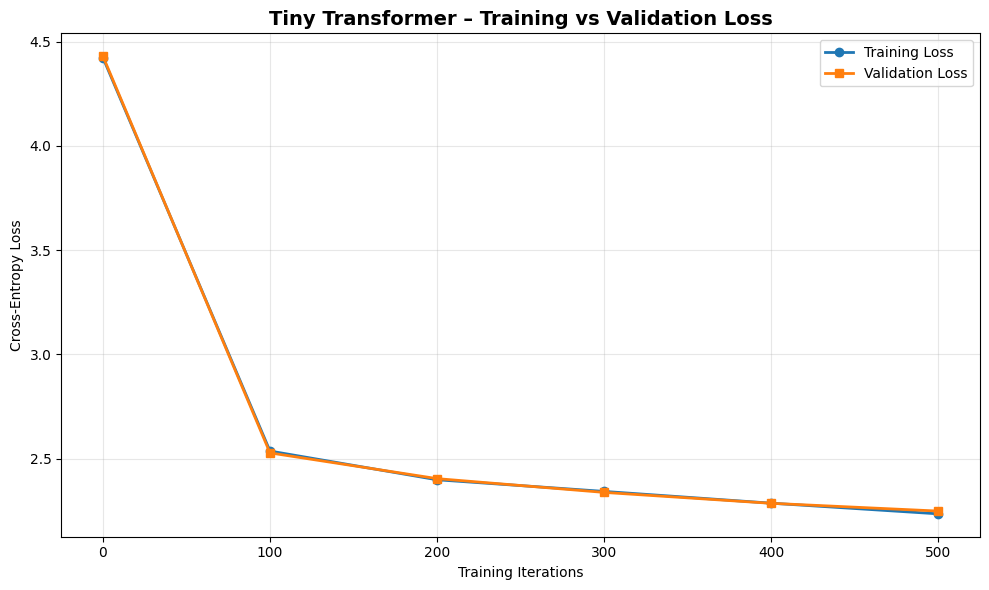

Loss curve saved successfully!


In [19]:

# Step 7.1: Plot Training and Validation Loss

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    eval_steps,
    train_losses,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    eval_steps,
    val_losses,
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

plt.title(
    "Tiny Transformer – Training vs Validation Loss",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Training Iterations")
plt.ylabel("Cross-Entropy Loss")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "tiny_transformer_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Loss curve saved successfully!")



### 9.2 Results and Interpretation

**Training Results:**

| Metric | Initial Value | Final Value |
|---|---:|---:|
| Training Loss | 4.4236 | 2.2345 |
| Validation Loss | 4.4304 | 2.2477 |

**Observations:**

1. Both training and validation losses decreased consistently throughout the 500 training iterations.
2. The largest reduction occurred during the first 100 iterations.
3. After 100 iterations, the loss continued to decrease at a slower rate.
4. The final difference between validation and training loss was approximately 0.0132.
5. The learning curves remained close throughout the experiment.

**Interpretation:**

The decreasing losses indicate that the Transformer learned useful character-level patterns from the TinyStories dataset.

The close alignment between training and validation curves suggests that the model generalized reasonably well to the selected validation data during this experiment.

There is no clear evidence of substantial overfitting within the first 500 iterations.

However, lower loss does not necessarily guarantee coherent story generation. The quality of generated text must be evaluated separately.

**Conclusion:**

The training experiment demonstrated successful optimization of the Tiny Transformer language model using next-token prediction and cross-entropy loss.



## 10. Task 8 – Model Evaluation and Perplexity

### 10.1 Evaluating the Trained Transformer

**Objective:** To evaluate the trained Transformer using cross-entropy loss and perplexity on the validation dataset.

**Evaluation Metrics:**

**Cross-Entropy Loss:** Measures how well the model predicts the correct next character.

**Perplexity:** Measures the model's uncertainty when predicting the next token.

**Formula:**

Perplexity = exp(Cross-Entropy Loss)

Lower validation loss and perplexity generally indicate better next-token prediction performance.

Because this model uses character-level tokenization, the reported perplexity is calculated per character token.

**Evaluation Method:**

The model is switched to evaluation mode, and gradient computation is disabled.

Loss is averaged across randomly sampled training and validation batches to estimate predictive performance.


In [20]:

# Step 8.1: Model Evaluation and Perplexity

import math

# Use more batches for evaluation
eval_iters = 100

# Reuse the evaluation function
evaluation_results = estimate_loss()

train_loss = evaluation_results["train"]
validation_loss = evaluation_results["val"]

# Calculate perplexity
train_perplexity = math.exp(train_loss)
validation_perplexity = math.exp(validation_loss)

print("=" * 50)
print("TINY TRANSFORMER - MODEL EVALUATION")
print("=" * 50)

print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {validation_loss:.4f}")

print(f"Training Perplexity : {train_perplexity:.4f}")
print(f"Validation Perplexity: {validation_perplexity:.4f}")

print(f"Generalization Gap  : {validation_loss - train_loss:.4f}")

print("=" * 50)
print("Evaluation Completed Successfully!")


TINY TRANSFORMER - MODEL EVALUATION
Training Loss       : 2.2472
Validation Loss     : 2.2468
Training Perplexity : 9.4613
Validation Perplexity: 9.4570
Generalization Gap  : -0.0005
Evaluation Completed Successfully!



### 10.2 Evaluation Results and Analysis

**Experimental Results**

| Evaluation Metric | Result |
|---|---:|
| Training Cross-Entropy Loss | 2.2472 |
| Validation Cross-Entropy Loss | 2.2468 |
| Training Perplexity | 9.4613 |
| Validation Perplexity | 9.4570 |
| Generalization Gap | Approximately -0.0005 |

**Observations:**

1. The training and validation losses were nearly identical.
2. The validation perplexity was approximately 9.46.
3. The model demonstrated a substantial reduction in cross-entropy loss compared with its initial untrained state.
4. No substantial generalization gap was observed in the sampled evaluation batches.

**Interpretation:**

The results indicate that the trained Transformer learned useful character-level patterns from the TinyStories dataset.

The small difference between training and validation losses suggests no clear evidence of significant overfitting at this stage.

However, the evaluation was based on randomly sampled batches rather than a complete exhaustive validation pass.

Furthermore, character-level perplexity cannot be directly compared with word-level or subword-level perplexity.

**Conclusion:**

The model completed its initial evaluation successfully. Further assessment through text generation is required to determine whether the learned patterns produce readable and coherent stories.



## 11. Task 9 – Story Generation

### 11.1 Autoregressive Text Generation

**Objective:** To generate new story text using the trained Tiny Transformer language model.

**Theory:**

Autoregressive text generation produces one token at a time.

At each generation step:

1. The current token sequence is provided to the Transformer.
2. The model predicts logits for the next character.
3. The logits are converted into probabilities using softmax.
4. A character is sampled from the probability distribution.
5. The sampled character is appended to the sequence.
6. The process repeats until the requested number of characters is generated.

**Context Window:**

The model supports a maximum context length of 128 characters.

During generation, only the most recent 128 characters are passed to the model when the sequence exceeds this length.

**Generation Prompt:**

"Once upon a time"

**Generation Length:**

300 new characters.

**Note:** The model was trained for only 500 iterations on a relatively small dataset subset. Generated text may contain spelling errors, incomplete words, or incoherent sentences.


In [21]:

# Step 9.1: Autoregressive Story Generation

@torch.no_grad()
def generate_text(model, prompt, max_new_tokens=300):
    model.eval()

    # Convert prompt into token IDs
    input_ids = torch.tensor(
        [encode(prompt)],
        dtype=torch.long,
        device=device
    )

    for _ in range(max_new_tokens):

        # Keep only the latest context window
        idx_cond = input_ids[:, -block_size:]

        # Predict next-character logits
        logits, _ = model(idx_cond)

        # Select logits at the last position
        logits = logits[:, -1, :]

        # Convert logits into probabilities
        probabilities = F.softmax(logits, dim=-1)

        # Sample next token
        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        )

        # Append token to the sequence
        input_ids = torch.cat(
            (input_ids, next_token),
            dim=1
        )

    # Convert token IDs back into text
    return decode(input_ids[0].tolist())


# Generate a new story
prompt = "Once upon a time"

generated_story = generate_text(
    model,
    prompt,
    max_new_tokens=300
)

print("=" * 60)
print("TINY TRANSFORMER - GENERATED STORY")
print("=" * 60)

print(generated_story)

print("\nGenerated Characters:", len(generated_story) - len(prompt))
print("Total Characters:", len(generated_story))


TINY TRANSFORMER - GENERATED STORY
Once upon a time bbang ro bise vig arings sheve pay wadiepa t souindfad te sofenouthe ithe a thesudo ar. wo id ting ald he way lytolelsi"
Sheca sQepauske it bo pp s t d.nithed ye Ba. go thede Shebet€€€;The ala ilde to s, cut hayd uy surss as. Titthece he fompin himed!"Yiak ay BiWe, fom. Thante wim. age fs irt. Ong 

Generated Characters: 300
Total Characters: 316



### 11.2 Generated Text Evaluation

**Generation Configuration**

| Parameter | Value |
|---|---|
| Prompt | Once upon a time |
| Generated Characters | 300 |
| Total Characters | 316 |
| Model Training Iterations | 500 |
| Tokenization | Character-level |
| Generation Method | Multinomial Sampling |

**Observations:**

1. The model successfully generated 300 new characters.
2. Some recognizable English character sequences and short words appeared.
3. The output contained numerous spelling errors and meaningless character combinations.
4. The generated text lacked coherent sentence structure and a meaningful storyline.
5. Some unusual symbols appeared in the output.

**Analysis:**

Although training and validation losses decreased substantially, the generated text remained largely incoherent.

This demonstrates that improved next-token prediction loss does not necessarily produce fluent or meaningful language.

Possible contributing factors include limited training iterations, a small Transformer architecture, and the difficulty of learning language structure using character-level tokens.

**Conclusion:**

The text generation pipeline was implemented successfully. However, the quality of the generated story indicates that further training and experimentation are necessary.

Future experiments will investigate whether additional training iterations and adjustments to model configuration improve generation quality.



## 12. Task 10 – Hyperparameter Experimentation

### 12.1 Experiment 2: Increasing Training Iterations

**Objective:** To investigate whether additional training iterations improve the Tiny Transformer's next-character prediction performance.

**Research Question:**

Does increasing the number of training iterations reduce validation loss and improve generated text quality?

**Experimental Design:**

The existing model will be trained for 2,000 additional iterations, increasing the total number of training updates from 501 to 2,501, including the initial single-step test.

The model architecture, learning rate, batch size, and context length will remain unchanged.

This allows us to investigate the effect of additional training while keeping the other configuration settings constant.

**Evaluation Criteria:**

- Training cross-entropy loss
- Validation cross-entropy loss
- Validation perplexity
- Generated text quality

**Hypothesis:**

Additional training may improve character-level language modeling performance and produce more recognizable English words and sentence structures.


In [22]:

# Step 10.1: Continue Training - Experiment 2

additional_iters = 2000
experiment_eval_interval = 250

exp2_steps = []
exp2_train_losses = []
exp2_val_losses = []

model.train()
start_time = time.time()

for step in range(1, additional_iters + 1):

    # Sample training batch
    xb, yb = get_batch("train")

    # Forward pass
    _, loss = model(xb, yb)

    # Backpropagation
    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    # Update parameters
    optimizer.step()

    # Periodic evaluation
    if step % experiment_eval_interval == 0:
        losses = estimate_loss()

        total_steps = 500 + step

        exp2_steps.append(total_steps)
        exp2_train_losses.append(losses["train"])
        exp2_val_losses.append(losses["val"])

        print(
            f"Total Steps {total_steps:4d} | "
            f"Train Loss: {losses['train']:.4f} | "
            f"Validation Loss: {losses['val']:.4f}"
        )

elapsed = time.time() - start_time

print("\nExperiment 2 Completed!")
print(f"Additional Training Time: {elapsed:.2f} seconds")
print(f"Final Training Loss: {exp2_train_losses[-1]:.4f}")
print(f"Final Validation Loss: {exp2_val_losses[-1]:.4f}")


Total Steps  750 | Train Loss: 2.1313 | Validation Loss: 2.1248
Total Steps 1000 | Train Loss: 1.9797 | Validation Loss: 1.9576
Total Steps 1250 | Train Loss: 1.8273 | Validation Loss: 1.7836
Total Steps 1500 | Train Loss: 1.7138 | Validation Loss: 1.6685
Total Steps 1750 | Train Loss: 1.6296 | Validation Loss: 1.5707
Total Steps 2000 | Train Loss: 1.5590 | Validation Loss: 1.5090
Total Steps 2250 | Train Loss: 1.5133 | Validation Loss: 1.4513
Total Steps 2500 | Train Loss: 1.4713 | Validation Loss: 1.4133

Experiment 2 Completed!
Additional Training Time: 35.83 seconds
Final Training Loss: 1.4713
Final Validation Loss: 1.4133


In [23]:

# Step 10.3: Generate Story After Additional Training

prompt = "Once upon a time"

improved_story = generate_text(
    model,
    prompt,
    max_new_tokens=300
)

print("=" * 60)
print("EXPERIMENT 2 - GENERATED STORY")
print("=" * 60)

print(improved_story)

print("\nGenerated Characters:", len(improved_story) - len(prompt))
print("Total Characters:", len(improved_story))


EXPERIMENT 2 - GENERATED STORY
Once upon a time the backless kidecided.
She uphat til all was all but she vfroking!" Iâ€ ran an named Tim lived and her cause day, it oksice." 
The toy said she flawine a loudeting near the cordrys the sopp and shoul ask, ol bug there girl storing friends and cad happy. His mum to anjoyed as home."

The sumplied a

Generated Characters: 300
Total Characters: 316



### 12.2 Experiment Results and Comparative Analysis

**Objective:** To evaluate the impact of additional training iterations on language modeling performance and generated text quality.

#### Quantitative Comparison

| Metric | Experiment 1 | Experiment 2 |
|---|---:|---:|
| Training Iterations (Reported) | 500 | 2,500 |
| Training Loss | 2.2345 | 1.4713 |
| Validation Loss | 2.2477 | 1.4133 |
| Generated Characters | 300 | 300 |

**Validation Loss Reduction:** Approximately 37.1%.

#### Qualitative Comparison

**Experiment 1:**

The generated output consisted mainly of meaningless character combinations, with limited recognizable English vocabulary and minimal sentence structure.

**Experiment 2:**

The generated output contained more recognizable English words, short phrases, and partial sentence structures.

Examples included:
- "named Tim lived"
- "The toy said"
- "friends and cad happy"

However, spelling errors, malformed words, grammatical inconsistencies, and incoherent narrative transitions remained.

#### Discussion

Increasing training iterations from 500 to 2,500 substantially reduced both training and validation losses.

The generated text also showed qualitative improvement, suggesting that additional training helped the model learn more useful character sequences and language patterns.

Nevertheless, the generated story was not fully grammatical or semantically coherent.

Because generation uses random sampling, a single output from each experiment provides only preliminary evidence of qualitative improvement.

#### Conclusion

The experiment supports the hypothesis that additional training improves next-character prediction performance.

Further experiments are required to evaluate the effects of Transformer architecture, attention heads, and training configuration on model performance.



### 12.3 Experiment 3 – Transformer Depth Comparison

**Objective:** To investigate how increasing the number of Transformer layers affects model capacity and language modeling performance.

**Research Question:**

Does a 4-layer Transformer achieve better validation loss than a 2-layer Transformer under comparable training conditions?

**Experimental Configuration:**

| Hyperparameter | Baseline Model | New Model |
|---|---|---|
| Transformer Layers | 2 | 4 |
| Attention Heads | 4 | 4 |
| Embedding Dimension | 128 | 128 |
| Context Length | 128 | 128 |
| Batch Size | 32 | 32 |
| Learning Rate | 0.0003 | 0.0003 |

**Hypothesis:**

Increasing Transformer depth may improve the model's ability to learn complex character-level patterns. However, additional layers increase parameter count and computational cost.

**Experimental Control:**

Both architectures should be compared using the same dataset, optimizer configuration, and training budget.


In [24]:

# Step 10.5: Create a Configurable Transformer

class ConfigurableTransformerLM(TinyTransformerLM):
    def __init__(self, num_layers=4):
        super().__init__()

        # Replace the original 2-layer stack
        self.blocks = nn.Sequential(
            *[
                TransformerBlock(n_embd, n_head)
                for _ in range(num_layers)
            ]
        )


# Create a NEW 4-layer model
model_4layers = ConfigurableTransformerLM(
    num_layers=4
).to(device)

# Count parameters
params_2layers = sum(
    p.numel() for p in model.parameters()
)

params_4layers = sum(
    p.numel() for p in model_4layers.parameters()
)

print("=" * 50)
print("TRANSFORMER ARCHITECTURE COMPARISON")
print("=" * 50)

print("2-Layer Model Parameters:", f"{params_2layers:,}")
print("4-Layer Model Parameters:", f"{params_4layers:,}")

print("\n2-Layer Transformer Blocks:", len(model.blocks))
print("4-Layer Transformer Blocks:", len(model_4layers.blocks))

print("\n4-Layer Model Created Successfully!")


TRANSFORMER ARCHITECTURE COMPARISON
2-Layer Model Parameters: 432,976
4-Layer Model Parameters: 828,752

2-Layer Transformer Blocks: 2
4-Layer Transformer Blocks: 4

4-Layer Model Created Successfully!



### 12.4 Training the 4-Layer Transformer

The 4-layer Transformer contains 828,752 trainable parameters, compared with 432,976 parameters in the original 2-layer architecture.

The new model will be trained from randomly initialized weights for 2,500 optimizer updates.

The following hyperparameters remain unchanged:

- Embedding dimension: 128
- Attention heads: 4
- Context length: 128
- Batch size: 32
- Learning rate: 0.0003
- Optimizer: AdamW

Training and validation losses will be evaluated every 250 updates.

This experiment investigates whether increasing Transformer depth improves character-level language modeling performance.

The comparison is based on approximately equal training-update budgets, although the larger model requires more computation per update.


In [25]:

# Step 10.6: Train the 4-Layer Transformer

import time

# Separate optimizer for the new model
optimizer_4layers = torch.optim.AdamW(
    model_4layers.parameters(),
    lr=3e-4
)

max_iters_4layers = 2500
eval_interval_4layers = 250

steps_4layers = []
train_losses_4layers = []
val_losses_4layers = []

@torch.no_grad()
def evaluate_4layers():
    results = {}
    model_4layers.eval()

    for split in ["train", "val"]:
        losses = []

        for _ in range(100):
            xb, yb = get_batch(split)
            _, loss = model_4layers(xb, yb)
            losses.append(loss.item())

        results[split] = sum(losses) / len(losses)

    model_4layers.train()
    return results


start_time_4layers = time.time()

model_4layers.train()

for step in range(1, max_iters_4layers + 1):

    xb, yb = get_batch("train")

    # Forward pass
    _, loss = model_4layers(xb, yb)

    # Backpropagation
    optimizer_4layers.zero_grad(set_to_none=True)
    loss.backward()
    optimizer_4layers.step()

    # Evaluation
    if step % eval_interval_4layers == 0:

        results = evaluate_4layers()

        steps_4layers.append(step)
        train_losses_4layers.append(results["train"])
        val_losses_4layers.append(results["val"])

        print(
            f"Step {step:4d} | "
            f"Train Loss: {results['train']:.4f} | "
            f"Validation Loss: {results['val']:.4f}"
        )

training_time_4layers = time.time() - start_time_4layers

print("\n" + "=" * 55)
print("4-LAYER TRANSFORMER TRAINING COMPLETED")
print("=" * 55)

print(f"Training Time: {training_time_4layers:.2f} seconds")
print(f"Final Training Loss: {train_losses_4layers[-1]:.4f}")
print(f"Final Validation Loss: {val_losses_4layers[-1]:.4f}")

print("=" * 55)


Step  250 | Train Loss: 2.3327 | Validation Loss: 2.3354
Step  500 | Train Loss: 2.2022 | Validation Loss: 2.1905
Step  750 | Train Loss: 2.0095 | Validation Loss: 1.9873
Step 1000 | Train Loss: 1.8059 | Validation Loss: 1.7609
Step 1250 | Train Loss: 1.6538 | Validation Loss: 1.6029
Step 1500 | Train Loss: 1.5494 | Validation Loss: 1.4906
Step 1750 | Train Loss: 1.4698 | Validation Loss: 1.4113
Step 2000 | Train Loss: 1.4117 | Validation Loss: 1.3604
Step 2250 | Train Loss: 1.3660 | Validation Loss: 1.3164
Step 2500 | Train Loss: 1.3295 | Validation Loss: 1.2851

4-LAYER TRANSFORMER TRAINING COMPLETED
Training Time: 82.39 seconds
Final Training Loss: 1.3295
Final Validation Loss: 1.2851


In [26]:

# Step 10.8: Fair Comparison Using Identical Validation Batches

import math

@torch.no_grad()
def compare_models(model_a, model_b, num_batches=100):

    model_a.eval()
    model_b.eval()

    losses_a = []
    losses_b = []

    for _ in range(num_batches):
        xb, yb = get_batch("val")

        # Same validation batch for both models
        _, loss_a = model_a(xb, yb)
        _, loss_b = model_b(xb, yb)

        losses_a.append(loss_a.item())
        losses_b.append(loss_b.item())

    return (
        sum(losses_a) / len(losses_a),
        sum(losses_b) / len(losses_b)
    )


loss_2layers, loss_4layers = compare_models(
    model,
    model_4layers
)

print("=" * 55)
print("FAIR VALIDATION COMPARISON")
print("=" * 55)

print(f"2-Layer Validation Loss : {loss_2layers:.4f}")
print(f"4-Layer Validation Loss : {loss_4layers:.4f}")

print(f"2-Layer Perplexity      : {math.exp(loss_2layers):.4f}")
print(f"4-Layer Perplexity      : {math.exp(loss_4layers):.4f}")

improvement = (
    (loss_2layers - loss_4layers) / loss_2layers
) * 100

print(f"Validation Loss Reduction: {improvement:.2f}%")

print("=" * 55)


FAIR VALIDATION COMPARISON
2-Layer Validation Loss : 1.4153
4-Layer Validation Loss : 1.2820
2-Layer Perplexity      : 4.1176
4-Layer Perplexity      : 3.6038
Validation Loss Reduction: 9.42%



### 12.5 Transformer Depth Comparison – Results and Discussion

**Objective:** To investigate the effect of Transformer depth on character-level language modeling performance.

#### Experimental Results

Both models were evaluated using the same 100 randomly sampled validation batches.

| Metric | 2-Layer Transformer | 4-Layer Transformer |
|---|---:|---:|
| Transformer Layers | 2 | 4 |
| Attention Heads | 4 | 4 |
| Trainable Parameters | 432,976 | 828,752 |
| Validation Loss | 1.4153 | 1.2820 |
| Validation Perplexity | 4.1176 | 3.6038 |

**Validation Loss Reduction:** 9.42%

#### Observations

1. The 4-layer Transformer achieved a lower validation loss than the 2-layer Transformer.
2. Validation perplexity decreased from 4.1176 to 3.6038.
3. Increasing Transformer depth approximately doubled the number of trainable parameters.
4. The deeper model demonstrated better next-character prediction performance on the sampled validation batches.

#### Discussion

The results suggest that increasing Transformer depth from two to four layers improved predictive performance under the experimental conditions.

Additional Transformer blocks provide more opportunities to transform token representations through self-attention and feed-forward operations.

However, the improved performance comes with increased parameter count and computational requirements.

The experiment compares models with approximately equal training-update budgets, rather than equal computational budgets. Differences in random initialization and training batches may also influence the results.

Therefore, the findings demonstrate an improvement in this experiment but do not establish that four layers are always optimal.

#### Conclusion

The 4-layer Transformer achieved better validation loss and perplexity than the 2-layer baseline.

This experiment highlights the trade-off between model capacity, predictive performance, and computational cost.



### 12.6 Experiment 4 – Attention Heads Comparison

**Objective:** To investigate how changing the number of self-attention heads affects Transformer language modeling performance.

**Research Question:**

Does increasing the number of attention heads from 4 to 8 improve validation loss and perplexity when Transformer depth and embedding dimension remain unchanged?

**Experimental Configuration:**

| Hyperparameter | Baseline | Experimental Model |
|---|---:|---:|
| Transformer Layers | 4 | 4 |
| Attention Heads | 4 | 8 |
| Embedding Dimension | 128 | 128 |
| Head Dimension | 32 | 16 |
| Context Length | 128 | 128 |
| Batch Size | 32 | 32 |
| Learning Rate | 0.0003 | 0.0003 |
| Training Updates | 2,500 | 2,500 |

**Hypothesis:**

Increasing the number of attention heads may help the Transformer capture different relationships between tokens.

However, more attention heads do not necessarily guarantee better performance, particularly when the total embedding dimension remains fixed.

**Experimental Control:**

Both models will use the same dataset, architecture depth, embedding dimension, optimizer configuration, and training-update budget.


In [27]:

# Step 10.10: Create an 8-Head Transformer

# Preserve the original global configuration
original_n_head = n_head

try:
    # Configure new attention head count
    n_head = 8

    # Create a separate 4-layer, 8-head model
    model_8heads = ConfigurableTransformerLM(
        num_layers=4
    ).to(device)

finally:
    # Restore original configuration
    n_head = original_n_head

# Count parameters
params_8heads = sum(
    p.numel() for p in model_8heads.parameters()
)

print("=" * 55)
print("ATTENTION HEADS ARCHITECTURE COMPARISON")
print("=" * 55)

print("4-Head Model Parameters:",
      f"{params_4layers:,}")

print("8-Head Model Parameters:",
      f"{params_8heads:,}")

print("\n4-Head Attention Heads:",
      len(model_4layers.blocks[0].sa.heads))

print("8-Head Attention Heads:",
      len(model_8heads.blocks[0].sa.heads))

print("\nEmbedding Dimension:", n_embd)
print("8-Head Dimension:", n_embd // 8)

print("\n8-Head Model Created Successfully!")


ATTENTION HEADS ARCHITECTURE COMPARISON
4-Head Model Parameters: 828,752
8-Head Model Parameters: 828,752

4-Head Attention Heads: 4
8-Head Attention Heads: 8

Embedding Dimension: 128
8-Head Dimension: 16

8-Head Model Created Successfully!



### 12.7 Training the 8-Head Transformer

**Objective:** To evaluate the effect of increasing the number of attention heads from 4 to 8 while keeping the Transformer depth and embedding dimension constant.

The experimental model contains four Transformer blocks, eight attention heads per block, and 828,752 trainable parameters.

Both the 4-head and 8-head models have the same parameter count because the total embedding dimension remains fixed at 128.

**Training Configuration:**

- Training iterations: 2,500
- Batch size: 32
- Context length: 128
- Embedding dimension: 128
- Learning rate: 0.0003
- Optimizer: AdamW
- Evaluation interval: 250 iterations

**Evaluation Method:**

Training and validation cross-entropy losses will be estimated periodically.

After training, both models will be evaluated on identical validation batches to compare loss and perplexity.

**Expected Outcome:**

The experiment will determine whether using more attention heads improves character-level next-token prediction under the selected training conditions.


In [28]:

# Step 10.11: Train the 8-Head Transformer

import time

optimizer_8heads = torch.optim.AdamW(
    model_8heads.parameters(),
    lr=3e-4
)

max_iters_8heads = 2500
eval_interval_8heads = 250

steps_8heads = []
train_losses_8heads = []
val_losses_8heads = []

@torch.no_grad()
def evaluate_8heads():
    results = {}
    model_8heads.eval()

    for split in ["train", "val"]:
        losses = []

        for _ in range(100):
            xb, yb = get_batch(split)
            _, loss = model_8heads(xb, yb)
            losses.append(loss.item())

        results[split] = sum(losses) / len(losses)

    model_8heads.train()
    return results


start_time_8heads = time.time()

model_8heads.train()

for step in range(1, max_iters_8heads + 1):

    xb, yb = get_batch("train")

    # Forward pass
    _, loss = model_8heads(xb, yb)

    # Backpropagation
    optimizer_8heads.zero_grad(set_to_none=True)
    loss.backward()
    optimizer_8heads.step()

    # Periodic evaluation
    if step % eval_interval_8heads == 0:

        results = evaluate_8heads()

        steps_8heads.append(step)
        train_losses_8heads.append(results["train"])
        val_losses_8heads.append(results["val"])

        print(
            f"Step {step:4d} | "
            f"Train Loss: {results['train']:.4f} | "
            f"Validation Loss: {results['val']:.4f}"
        )

training_time_8heads = time.time() - start_time_8heads

print("\n" + "=" * 55)
print("8-HEAD TRANSFORMER TRAINING COMPLETED")
print("=" * 55)

print(f"Training Time: {training_time_8heads:.2f} seconds")
print(f"Final Training Loss: {train_losses_8heads[-1]:.4f}")
print(f"Final Validation Loss: {val_losses_8heads[-1]:.4f}")
print("=" * 55)


Step  250 | Train Loss: 2.3344 | Validation Loss: 2.3402
Step  500 | Train Loss: 2.1930 | Validation Loss: 2.1814
Step  750 | Train Loss: 1.9991 | Validation Loss: 1.9812
Step 1000 | Train Loss: 1.8055 | Validation Loss: 1.7703
Step 1250 | Train Loss: 1.6640 | Validation Loss: 1.6202
Step 1500 | Train Loss: 1.5678 | Validation Loss: 1.5234
Step 1750 | Train Loss: 1.4959 | Validation Loss: 1.4395
Step 2000 | Train Loss: 1.4383 | Validation Loss: 1.3875
Step 2250 | Train Loss: 1.3937 | Validation Loss: 1.3329
Step 2500 | Train Loss: 1.3533 | Validation Loss: 1.2951

8-HEAD TRANSFORMER TRAINING COMPLETED
Training Time: 137.51 seconds
Final Training Loss: 1.3533
Final Validation Loss: 1.2951


In [29]:

# Step 10.13: Fair Attention Heads Comparison

import math

# Reuse the comparison function from Experiment 3
loss_4heads, loss_8heads = compare_models(
    model_4layers,
    model_8heads,
    num_batches=100
)

ppl_4heads = math.exp(loss_4heads)
ppl_8heads = math.exp(loss_8heads)

print("=" * 55)
print("ATTENTION HEADS - FAIR VALIDATION COMPARISON")
print("=" * 55)

print(f"4-Head Validation Loss : {loss_4heads:.4f}")
print(f"8-Head Validation Loss : {loss_8heads:.4f}")

print(f"4-Head Perplexity      : {ppl_4heads:.4f}")
print(f"8-Head Perplexity      : {ppl_8heads:.4f}")

loss_difference = loss_8heads - loss_4heads

print(f"Loss Difference (8 - 4): {loss_difference:+.4f}")

if loss_4heads < loss_8heads:
    print("\nLower Validation Loss: 4-Head Model")
elif loss_8heads < loss_4heads:
    print("\nLower Validation Loss: 8-Head Model")
else:
    print("\nBoth Models Have Equal Validation Loss")

print("=" * 55)



ATTENTION HEADS - FAIR VALIDATION COMPARISON
4-Head Validation Loss : 1.2871
8-Head Validation Loss : 1.3029
4-Head Perplexity      : 3.6222
8-Head Perplexity      : 3.6801
Loss Difference (8 - 4): +0.0159

Lower Validation Loss: 4-Head Model



### 12.8 Attention Heads Comparison – Results and Discussion

**Objective:** To investigate the effect of increasing the number of attention heads from 4 to 8 in a four-layer Transformer language model.

#### Experimental Results

Both models were evaluated using the same 100 randomly sampled validation batches.

| Metric | 4-Head Transformer | 8-Head Transformer |
|---|---:|---:|
| Transformer Layers | 4 | 4 |
| Attention Heads | 4 | 8 |
| Embedding Dimension | 128 | 128 |
| Dimension per Head | 32 | 16 |
| Trainable Parameters | 828,752 | 828,752 |
| Validation Loss | 1.2871 | 1.3029 |
| Validation Perplexity | 3.6222 | 3.6801 |
| Training Time | 82.39 s | 137.51 s |

#### Observations

1. The 4-head Transformer achieved a slightly lower validation loss than the 8-head Transformer.
2. The 4-head model also achieved lower validation perplexity.
3. Both architectures contained the same number of trainable parameters.
4. The 8-head model required more training time in this experimental run.
5. Increasing the number of attention heads did not improve predictive performance under the tested conditions.

#### Discussion

Increasing the number of attention heads allows the Transformer to compute attention through more parallel heads.

However, when the total embedding dimension remains fixed, increasing the number of heads reduces the dimensionality of each head.

In this experiment, the 4-head model achieved slightly better validation performance despite having fewer attention heads.

The difference in validation loss was small, and the results may be affected by random initialization, training batch sampling, and other experimental variability.

The observed training-time difference is specific to the implementation and execution environment and should not be interpreted as a universal computational comparison.

#### Conclusion

The experiment demonstrates that increasing attention head count does not necessarily improve language modeling performance.

For the tested configuration, four attention heads provided a slightly better balance between validation performance and measured training time.

Further repeated experiments would be required to determine whether this difference is consistent.



### 12.9 Final Transformer Model Comparison

**Objective:** To compare the three trained Transformer configurations and identify the model with the lowest validation loss.

**Models:**

- Model A: 2 Transformer layers and 4 attention heads.
- Model B: 4 Transformer layers and 4 attention heads.
- Model C: 4 Transformer layers and 8 attention heads.

All models use character-level tokenization, an embedding dimension of 128, and a context length of 128.

**Evaluation Method:**

The three trained models will be evaluated using identical randomly sampled validation batches.

The comparison will consider:

- Validation cross-entropy loss
- Validation perplexity
- Trainable parameter count

**Selection Criterion:**

The model with the lowest estimated validation cross-entropy loss will be selected as the best-performing model for this experiment.

**Limitation:**

The comparison is based on one trained instance of each configuration and sampled validation batches. Repeated runs would be necessary to establish the consistency of the findings.


In [30]:

# Step 10.15: Final Three-Model Comparison

import math
import pandas as pd

models_to_compare = {
    "Model A - 2 Layers, 4 Heads": model,
    "Model B - 4 Layers, 4 Heads": model_4layers,
    "Model C - 4 Layers, 8 Heads": model_8heads
}

# Use identical validation batches for all models
torch.manual_seed(42)

validation_batches = [
    get_batch("val")
    for _ in range(100)
]

results = []

with torch.no_grad():
    for model_name, current_model in models_to_compare.items():

        current_model.eval()
        batch_losses = []

        for xb, yb in validation_batches:
            _, loss = current_model(xb, yb)
            batch_losses.append(loss.item())

        avg_loss = sum(batch_losses) / len(batch_losses)

        results.append({
            "Model": model_name,
            "Parameters": sum(
                p.numel() for p in current_model.parameters()
            ),
            "Validation Loss": round(avg_loss, 4),
            "Perplexity": round(math.exp(avg_loss), 4)
        })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Validation Loss"
).reset_index(drop=True)

print("=" * 65)
print("FINAL TRANSFORMER MODEL COMPARISON")
print("=" * 65)

print(comparison_df.to_string(index=False))

print("\nBEST PERFORMING MODEL:")
print(comparison_df.iloc[0]["Model"])

print("=" * 65)


FINAL TRANSFORMER MODEL COMPARISON
                      Model  Parameters  Validation Loss  Perplexity
Model B - 4 Layers, 4 Heads      828752           1.2815      3.6021
Model C - 4 Layers, 8 Heads      828752           1.2956      3.6533
Model A - 2 Layers, 4 Heads      432976           1.4154      4.1182

BEST PERFORMING MODEL:
Model B - 4 Layers, 4 Heads



### 12.10 Final Model Comparison and Selection

**Objective:** To identify the best-performing Transformer configuration based on validation cross-entropy loss and perplexity.

#### Final Experimental Results

All three models were evaluated using the same 100 randomly sampled validation batches.

| Rank | Model | Layers | Heads | Parameters | Validation Loss | Perplexity |
|---|---|---:|---:|---:|---:|---:|
| 1 | Model B | 4 | 4 | 828,752 | 1.2815 | 3.6021 |
| 2 | Model C | 4 | 8 | 828,752 | 1.2956 | 3.6533 |
| 3 | Model A | 2 | 4 | 432,976 | 1.4154 | 4.1182 |

#### Key Findings

1. **Transformer Depth:** Increasing the number of Transformer layers from two to four improved validation performance in the tested configurations.

2. **Attention Heads:** Increasing the number of attention heads from four to eight did not improve validation performance in this experiment.

3. **Model Capacity:** The four-layer architectures contained more trainable parameters than the two-layer baseline.

4. **Model Selection:** Model B achieved the lowest validation loss and perplexity among the evaluated configurations.

#### Selected Model

**Model B – 4-Layer, 4-Head Transformer**

- Transformer layers: 4
- Attention heads: 4
- Embedding dimension: 128
- Context length: 128
- Trainable parameters: 828,752
- Validation cross-entropy loss: 1.2815
- Validation perplexity: 3.6021

#### Discussion

The experiments demonstrated that Transformer architecture choices influence character-level language modeling performance.

Increasing model depth improved next-token prediction performance, while increasing attention head count did not produce an additional improvement in this experimental setting.

The selected model achieved the lowest validation loss among the three trained configurations.

However, these findings are based on single training runs and sampled validation batches. Additional experiments with multiple random seeds would provide stronger evidence.

#### Conclusion

Model B was selected as the best-performing configuration based on the lowest observed validation cross-entropy loss.

The final model will be saved with its trained parameters, architecture configuration, and character-level vocabulary for future inference and reproducibility.



## 13. Task 11 – Model Saving and Reproducibility

### 13.1 Saving the Best Transformer Model

**Objective:** To save the best-performing trained Transformer and its configuration for future inference and reproducibility.

**Selected Model:** Model B – 4-Layer, 4-Head Transformer.

**Validation Results:**

- Validation Loss: 1.2815
- Validation Perplexity: 3.6021
- Trainable Parameters: 828,752

**Saved Artifacts:**

1. `best_transformer_model.pth` – Trained model parameters.
2. `model_config.json` – Model architecture, training settings, and evaluation results.
3. `tokenizer_vocab.json` – Character vocabulary used for encoding and decoding.

**Reproducibility:**

Saving the model weights and vocabulary allows the trained model to be reconstructed for inference without repeating the training process.

The same model architecture and vocabulary mapping must be used when loading the saved weights.


In [31]:

# Step 11.1: Save Best Transformer Model

import os
import json
import torch

# Create folder for model artifacts
save_dir = "tiny_transformer_artifacts"
os.makedirs(save_dir, exist_ok=True)

# 1. Save trained model weights
model_path = os.path.join(
    save_dir, "best_transformer_model.pth"
)

torch.save(
    model_4layers.state_dict(),
    model_path
)

# 2. Save model configuration
config = {
    "model_name": "TinyTransformerLM",
    "selected_model": "Model B",
    "num_layers": 4,
    "num_heads": 4,
    "embedding_dim": n_embd,
    "block_size": block_size,
    "vocab_size": vocab_size,
    "batch_size": batch_size,
    "learning_rate": 0.0003,
    "training_iterations": 2500,
    "validation_loss": 1.2815,
    "validation_perplexity": 3.6021,
    "num_parameters": 828752,
    "tokenizer_type": "character-level"
}

config_path = os.path.join(
    save_dir, "model_config.json"
)

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4)

# 3. Save character vocabulary
vocab_path = os.path.join(
    save_dir, "tokenizer_vocab.json"
)

with open(vocab_path, "w", encoding="utf-8") as f:
    json.dump(
        {"chars": chars},
        f,
        ensure_ascii=False,
        indent=4
    )

# 4. Verify saved files
print("=" * 55)
print("BEST TRANSFORMER MODEL - SAVED ARTIFACTS")
print("=" * 55)

for filename in os.listdir(save_dir):
    filepath = os.path.join(save_dir, filename)
    file_size = os.path.getsize(filepath) / 1024

    print(f"{filename} | {file_size:.2f} KB")

print("=" * 55)
print("Model Artifacts Saved Successfully!")


BEST TRANSFORMER MODEL - SAVED ARTIFACTS
model_config.json | 0.40 KB
best_transformer_model.pth | 4302.23 KB
tokenizer_vocab.json | 1.05 KB
Model Artifacts Saved Successfully!



### 13.2 Loading and Verifying the Saved Model

**Objective:** To verify that the saved Transformer model can be reconstructed and loaded successfully without retraining.

**Verification Procedure:**

1. Load the saved model configuration and tokenizer vocabulary.
2. Reconstruct the selected Transformer architecture.
3. Load the saved model weights.
4. Compare the original model's predictions with the reloaded model's predictions using identical input data.

**Expected Result:**

The original and reloaded models should produce identical predictions within floating-point precision.

Successful verification demonstrates that the saved model weights can be restored for future inference.


In [32]:

# Step 11.2: Load and Verify Saved Transformer

import json
import torch

# 1. Load configuration
with open(config_path, "r", encoding="utf-8") as f:
    loaded_config = json.load(f)

# 2. Load tokenizer vocabulary
with open(vocab_path, "r", encoding="utf-8") as f:
    loaded_vocab = json.load(f)

# Verify saved vocabulary
assert loaded_vocab["chars"] == chars
assert loaded_config["vocab_size"] == len(loaded_vocab["chars"])

# 3. Reconstruct the saved architecture
assert loaded_config["num_heads"] == n_head
assert loaded_config["embedding_dim"] == n_embd
assert loaded_config["block_size"] == block_size

reloaded_model = ConfigurableTransformerLM(
    num_layers=loaded_config["num_layers"]
).to(device)

# 4. Load trained weights
state_dict = torch.load(
    model_path,
    map_location=device,
    weights_only=True
)

reloaded_model.load_state_dict(state_dict)

# 5. Switch both models to evaluation mode
model_4layers.eval()
reloaded_model.eval()

# 6. Compare predictions using identical input
test_input = torch.tensor(
    [encode("Once upon a time")],
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    original_logits, _ = model_4layers(test_input)
    reloaded_logits, _ = reloaded_model(test_input)

# 7. Verify numerical equivalence
max_difference = (
    original_logits - reloaded_logits
).abs().max().item()

is_identical = torch.allclose(
    original_logits,
    reloaded_logits,
    atol=1e-6,
    rtol=1e-5
)

print("=" * 55)
print("SAVED MODEL VERIFICATION")
print("=" * 55)

print("Selected Model:", loaded_config["selected_model"])
print("Transformer Layers:", loaded_config["num_layers"])
print("Attention Heads:", loaded_config["num_heads"])
print("Vocabulary Size:", loaded_config["vocab_size"])

print(f"\nMaximum Prediction Difference: {max_difference:.10f}")
print("Predictions Match:", is_identical)

if is_identical:
    print("\nModel Reload Verification PASSED!")
else:
    print("\nModel Reload Verification FAILED!")

print("=" * 55)


SAVED MODEL VERIFICATION
Selected Model: Model B
Transformer Layers: 4
Attention Heads: 4
Vocabulary Size: 80

Maximum Prediction Difference: 0.0000000000
Predictions Match: True

Model Reload Verification PASSED!



### 13.3 Model Persistence and Backup

**Objective:** To preserve the trained Transformer model and its supporting artifacts beyond the temporary Google Colab runtime.

The saved model was successfully reloaded, and its predictions matched the original model.

To ensure long-term accessibility, the following artifacts are backed up to Google Drive:

- `best_transformer_model.pth`
- `model_config.json`
- `tokenizer_vocab.json`

The backup allows the trained model and tokenizer to be reused without repeating the training process.

The notebook containing the model architecture definitions must also be preserved to reconstruct the model in a new environment.


In [33]:

# Step 11.3: Backup Model Artifacts to Google Drive

from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount("/content/drive")

# Create permanent backup folder
backup_dir = (
    "/content/drive/MyDrive/"
    "PUSL3205_Lab03_TinyTransformer"
)

os.makedirs(backup_dir, exist_ok=True)

# Copy all saved model artifacts
for filename in [
    "best_transformer_model.pth",
    "model_config.json",
    "tokenizer_vocab.json"
]:
    source = os.path.join(save_dir, filename)
    destination = os.path.join(backup_dir, filename)

    shutil.copy2(source, destination)

    print(f"Backed up: {filename}")

# Verify backup files
print("\n" + "=" * 55)
print("GOOGLE DRIVE BACKUP VERIFICATION")
print("=" * 55)

for filename in [
    "best_transformer_model.pth",
    "model_config.json",
    "tokenizer_vocab.json"
]:
    backup_path = os.path.join(backup_dir, filename)

    exists = os.path.isfile(backup_path)

    print(f"{filename}: {'OK' if exists else 'MISSING'}")

print("\nBackup Location:")
print(backup_dir)
print("=" * 55)


Mounted at /content/drive
Backed up: best_transformer_model.pth
Backed up: model_config.json
Backed up: tokenizer_vocab.json

GOOGLE DRIVE BACKUP VERIFICATION
best_transformer_model.pth: OK
model_config.json: OK
tokenizer_vocab.json: OK

Backup Location:
/content/drive/MyDrive/PUSL3205_Lab03_TinyTransformer



## 14. Final Experimental Visualization

### 14.1 Transformer Architecture Comparison

**Objective:** To visualize and compare the validation performance of the three trained Transformer configurations.

Two bar charts are generated:

1. Validation Cross-Entropy Loss Comparison
2. Validation Perplexity Comparison

Both metrics are evaluated on identical sampled validation batches, and lower values indicate better predictive performance.

The visualizations help identify the most effective architecture among the evaluated configurations.


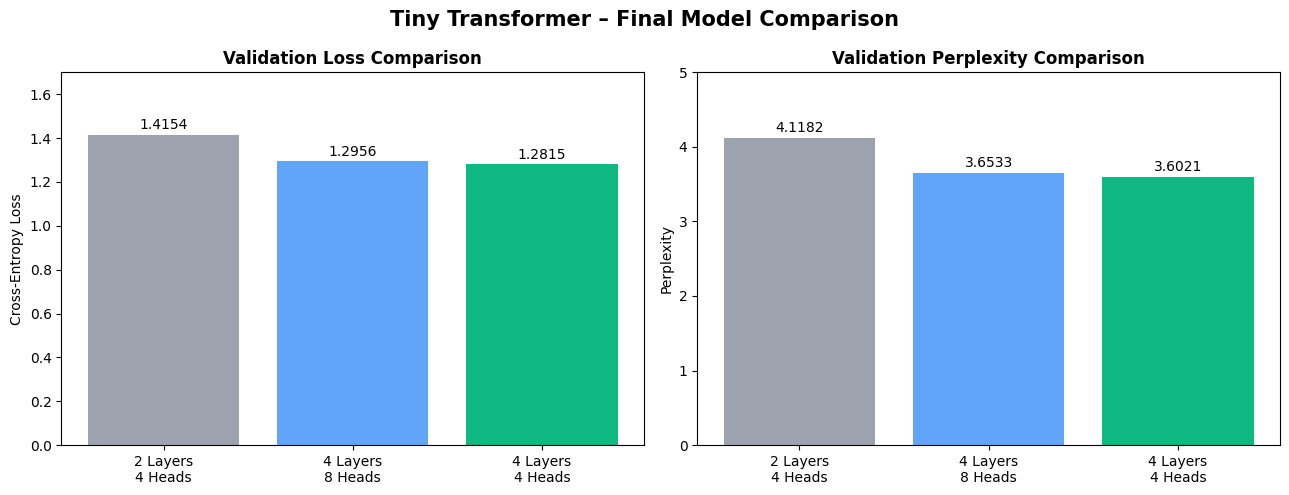

Final comparison chart saved to:
/content/drive/MyDrive/PUSL3205_Lab03_TinyTransformer/final_model_comparison.png


In [34]:

# Step 12.1: Final Model Comparison Visualization

import matplotlib.pyplot as plt
import os

# Sort models for consistent chart order
plot_df = comparison_df.sort_values(
    by="Validation Loss",
    ascending=False
)

model_labels = [
    "2 Layers\n4 Heads",
    "4 Layers\n8 Heads",
    "4 Layers\n4 Heads"
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Validation Loss
bars1 = axes[0].bar(
    model_labels,
    plot_df["Validation Loss"],
    color=["#9CA3AF", "#60A5FA", "#10B981"]
)

axes[0].set_title(
    "Validation Loss Comparison",
    fontweight="bold"
)
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_ylim(0, 1.7)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{bar.get_height():.4f}",
        ha="center"
    )

# Chart 2: Perplexity
bars2 = axes[1].bar(
    model_labels,
    plot_df["Perplexity"],
    color=["#9CA3AF", "#60A5FA", "#10B981"]
)

axes[1].set_title(
    "Validation Perplexity Comparison",
    fontweight="bold"
)
axes[1].set_ylabel("Perplexity")
axes[1].set_ylim(0, 5)

for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f"{bar.get_height():.4f}",
        ha="center"
    )

fig.suptitle(
    "Tiny Transformer – Final Model Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

# Save chart to Google Drive backup folder
chart_path = os.path.join(
    backup_dir,
    "final_model_comparison.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final comparison chart saved to:")
print(chart_path)



## 15. Bonus Task – Interactive Gradio Interface

### 15.1 Building a User Interface for the Tiny Transformer

**Objective:** To create a simple interactive web interface that allows users to enter text prompts and generate continuations using the trained Tiny Transformer language model.

**Technology:** Gradio

**Selected Model:** 4-Layer, 4-Head Transformer

The interface will accept user input, pass the prompt to the trained character-level language model, and display generated text.

**Limitation:** The model is trained for next-character prediction on TinyStories. It is not an instruction-tuned chatbot, so its outputs may be incomplete, repetitive, or unrelated to conversational questions.


In [35]:

# Step 12.2: Install Gradio

!pip -q install gradio

import gradio as gr

print("=" * 50)
print("GRADIO INSTALLATION")
print("=" * 50)
print("Gradio Version:", gr.__version__)
print("Gradio Installed Successfully!")
print("=" * 50)


GRADIO INSTALLATION
Gradio Version: 6.29.0
Gradio Installed Successfully!



### 15.2 Interactive Chat Interface Implementation

**Objective:** To develop an interactive chat-style interface using Gradio and the trained Tiny Transformer language model.

**Implementation:**

- Gradio is used to create the web interface.
- The best-performing 4-layer, 4-head Transformer is used for text generation.
- Users can enter a text prompt and receive a generated continuation.
- The interface maintains a visible conversation history.

**Limitation:** The character-level Transformer is trained on TinyStories rather than conversational instruction-response pairs. Therefore, its outputs represent generated story continuations, not reliable conversational answers.


In [36]:

# Step 15.2: Gradio AI Chat Interface

import gradio as gr
import torch

# Use the best-performing trained model
chat_model = reloaded_model
chat_model.eval()

def tiny_transformer_chat(message, history):
    if not message.strip():
        return "Please enter a story prompt."

    try:
        generated = generate_text(
            chat_model,
            message,
            max_new_tokens=200
        )

        # Display only the newly generated continuation
        if generated.startswith(message):
            continuation = generated[len(message):]
        else:
            continuation = generated

        return continuation.strip() or "(No text generated)"

    except Exception as e:
        return f"Generation error: {str(e)}"

demo = gr.ChatInterface(
    fn=tiny_transformer_chat,
    title="Tiny Transformer AI",
    description=(
        "Character-Level Story Generation | "
        "4 Transformer Layers | 4 Attention Heads"
    ),
    examples=[
        "Once upon a time",
        "There was a little girl",
        "One day, a boy",
        "The little cat"
    ]
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://69dc214cdfdd4d16bd.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



### 15.3 Gradio Interface Testing and Output Analysis

**Test Prompt:** "Once upon a time"

**Generated Output (Excerpt):**

> but he gave diful up and fund and he didn't gintarden wanted to exite laking. It he haid, they were brubble doce.

#### Observations

The Gradio interface successfully accepted a text prompt and displayed generated text from the trained Transformer.

The model produced recognizable English words and sentence-like structures. However, the generated output contained spelling errors, grammatical inconsistencies, and incoherent phrases.

#### Discussion

The results demonstrate that the Transformer learned some character-level language patterns from the TinyStories dataset.

However, the model has not yet developed reliable long-range narrative coherence or grammatical accuracy.

Possible contributing factors include the limited training dataset, relatively small model architecture, and limited training duration.

#### Conclusion

The Gradio interface was successfully implemented and tested.

Although the generated text remains imperfect, the experiment demonstrates the complete workflow from training a Transformer language model to deploying it through an interactive web interface.


In [37]:

# Step 16.1: Improved Text Generation
# Temperature + Top-k Sampling

import torch
import torch.nn.functional as F

@torch.no_grad()
def generate_improved(
    model,
    prompt="Once upon a time",
    max_new_tokens=400,
    temperature=0.7,
    top_k=20
):
    model.eval()

    input_ids = torch.tensor(
        [encode(prompt)],
        dtype=torch.long,
        device=device
    )

    for _ in range(max_new_tokens):

        context = input_ids[:, -block_size:]

        logits, _ = model(context)

        # Get next-character predictions
        logits = logits[:, -1, :]

        # Temperature scaling
        logits = logits / temperature

        # Top-k filtering
        k = min(top_k, logits.size(-1))

        values, _ = torch.topk(logits, k)

        logits[logits < values[:, [-1]]] = float("-inf")

        # Sample next character
        probabilities = F.softmax(logits, dim=-1)

        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        )

        input_ids = torch.cat(
            [input_ids, next_token],
            dim=1
        )

    return decode(input_ids[0].tolist())


# Generate an improved story
torch.manual_seed(42)

story = generate_improved(
    model_4layers,
    prompt="Once upon a time",
    max_new_tokens=400,
    temperature=0.7,
    top_k=20
)

print("=" * 60)
print("IMPROVED TINY TRANSFORMER STORY")
print("=" * 60)
print(story)
print("=" * 60)


IMPROVED TINY TRANSFORMER STORY
Once upon a time, they heard was going beautiful to help. They watched the boat was it beaughtiful her findow and make running on the ground, her said, â€œI crie not neever was him frow. I was the was spilly notick to the boy fun. She was so proud her where safe.

But then they was suns a laughing, a but the her shared she her and they in things oat a threat was snew the sunsurpled to sturp. They for her lots one


In [38]:

# Step 16.2: Check GPU Resources for Improved Training

import torch

print("=" * 60)
print("GPU RESOURCE CHECK")
print("=" * 60)

if torch.cuda.is_available():

    gpu_name = torch.cuda.get_device_name(0)

    total_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    allocated_memory = (
        torch.cuda.memory_allocated(0)
        / (1024 ** 3)
    )

    reserved_memory = (
        torch.cuda.memory_reserved(0)
        / (1024 ** 3)
    )

    print("GPU:", gpu_name)
    print(f"Total GPU Memory: {total_memory:.2f} GB")
    print(f"Allocated Memory: {allocated_memory:.2f} GB")
    print(f"Reserved Memory: {reserved_memory:.2f} GB")

else:
    print("GPU not available")

print("\nCurrent Model Parameters:")
print(sum(p.numel() for p in model_4layers.parameters()))

print("\nCurrent Dataset:")
print("Training Tokens:", len(train_data))
print("Validation Tokens:", len(val_data))

print("=" * 60)


GPU RESOURCE CHECK
GPU: Tesla T4
Total GPU Memory: 14.56 GB
Allocated Memory: 0.14 GB
Reserved Memory: 0.33 GB

Current Model Parameters:
828752

Current Dataset:
Training Tokens: 1702919
Validation Tokens: 155395



## 16. Improving the Tiny Transformer Language Model

### 16.1 Expanding the Training Dataset

**Objective:** To improve the linguistic quality and coherence of generated stories by increasing the amount of training data.

The original model was trained using 2,000 TinyStories training examples.

For the improvement experiment, the dataset will be expanded to:

- Training stories: 10,000
- Validation stories: 500

The existing Transformer architecture will initially remain unchanged.

**Hypothesis:** Additional training data may help the model learn a wider range of vocabulary, grammatical patterns, and narrative structures.

**Experimental Note:** Increasing the dataset size alone does not guarantee better generation quality. The improved model will require training and evaluation to determine whether meaningful improvements occur.


In [39]:

# Step 16.3: Expand TinyStories Dataset

from datasets import load_dataset
import torch

print("=" * 60)
print("EXPANDING TINYSTORIES DATASET")
print("=" * 60)

# Load larger subsets
expanded_train = load_dataset(
    "roneneldan/TinyStories",
    split="train[:10000]"
)

expanded_val = load_dataset(
    "roneneldan/TinyStories",
    split="validation[:500]"
)

# Combine story texts
expanded_train_text = "\n".join(
    expanded_train["text"]
)

expanded_val_text = "\n".join(
    expanded_val["text"]
)

# Build vocabulary for the improved model
improved_chars = sorted(
    set(expanded_train_text + expanded_val_text)
)

improved_stoi = {
    ch: i for i, ch in enumerate(improved_chars)
}

improved_itos = {
    i: ch for i, ch in enumerate(improved_chars)
}

def improved_encode(text):
    return [improved_stoi[ch] for ch in text]

def improved_decode(ids):
    return "".join(improved_itos[i] for i in ids)

# Convert text into token tensors
improved_train_data = torch.tensor(
    improved_encode(expanded_train_text),
    dtype=torch.long
)

improved_val_data = torch.tensor(
    improved_encode(expanded_val_text),
    dtype=torch.long
)

improved_vocab_size = len(improved_chars)

print("Training Stories:", len(expanded_train))
print("Validation Stories:", len(expanded_val))
print("Vocabulary Size:", improved_vocab_size)
print("Training Tokens:", len(improved_train_data))
print("Validation Tokens:", len(improved_val_data))

print("\nDataset Expansion Completed!")
print("=" * 60)


EXPANDING TINYSTORIES DATASET
Training Stories: 10000
Validation Stories: 500
Vocabulary Size: 92
Training Tokens: 8684760
Validation Tokens: 405580

Dataset Expansion Completed!



### 16.2 Preparing Training Batches for the Expanded Dataset

**Objective:** To prepare input-target sequence pairs for training the improved Transformer model.

The expanded TinyStories dataset contains 10,000 training stories and 500 validation stories.

Each training batch contains input sequences and corresponding target sequences shifted by one character.

**Training Configuration:**

- Batch size: 32
- Context length: 128 characters
- Tokenization: Character-level
- Vocabulary size: 92
- Device: CUDA GPU

The original training pipeline is preserved to allow comparison with the improved model.


In [40]:

# Step 16.4: Prepare Improved Training Batches

improved_batch_size = 32
improved_block_size = 128

def get_improved_batch(split):

    data = (
        improved_train_data
        if split == "train"
        else improved_val_data
    )

    # Random starting positions
    ix = torch.randint(
        len(data) - improved_block_size,
        (improved_batch_size,)
    )

    # Input sequences
    x = torch.stack([
        data[i:i + improved_block_size]
        for i in ix
    ])

    # Target sequences shifted by one character
    y = torch.stack([
        data[i + 1:i + improved_block_size + 1]
        for i in ix
    ])

    return x.to(device), y.to(device)


# Test training batch
xb, yb = get_improved_batch("train")

print("=" * 60)
print("IMPROVED TRAINING BATCH VERIFICATION")
print("=" * 60)

print("Input Shape :", xb.shape)
print("Target Shape:", yb.shape)

print("\nSample Input:")
print(improved_decode(xb[0].tolist())[:150])

print("\nSample Target:")
print(improved_decode(yb[0].tolist())[:150])

print("\nBatch Preparation Successful!")
print("=" * 60)


IMPROVED TRAINING BATCH VERIFICATION
Input Shape : torch.Size([32, 128])
Target Shape: torch.Size([32, 128])

Sample Input:
 wished he was nicer to her. She decided to tell her mom what happened. Maybe she could get a new peach crayon. She hoped so. Sh

Sample Target:
wished he was nicer to her. She decided to tell her mom what happened. Maybe she could get a new peach crayon. She hoped so. She

Batch Preparation Successful!



### 16.3 Initializing the Improved Transformer

**Objective:** To initialize a new Transformer language model for training on the expanded TinyStories dataset.

The improved model uses the same core architecture as the previously selected best-performing Transformer:

- 4 Transformer layers
- 4 attention heads
- Embedding dimension of 128
- Context length of 128

The vocabulary size is updated from 80 to 92 characters to accommodate the expanded dataset.

A separate model instance and optimizer are created to preserve the original trained model.

**Experimental Design:** The architecture is held constant while the training dataset and training procedure are expanded. Performance will be assessed using validation loss, perplexity, and generated text quality.


In [41]:

# Step 16.5: Initialize Improved Transformer

import torch

# Preserve original vocabulary size
original_vocab_size = vocab_size

try:
    # Temporarily use expanded vocabulary
    vocab_size = improved_vocab_size

    # Create a NEW model with 4 layers
    improved_model = ConfigurableTransformerLM(
        num_layers=4
    ).to(device)

finally:
    # Restore original vocabulary setting
    vocab_size = original_vocab_size

# Create separate optimizer
improved_optimizer = torch.optim.AdamW(
    improved_model.parameters(),
    lr=3e-4
)

# Count model parameters
improved_parameters = sum(
    p.numel()
    for p in improved_model.parameters()
)

# Test forward pass
xb, yb = get_improved_batch("train")

with torch.no_grad():
    logits, loss = improved_model(xb, yb)

print("=" * 60)
print("IMPROVED TRANSFORMER INITIALIZATION")
print("=" * 60)

print("Transformer Layers : 4")
print("Attention Heads    : 4")
print("Embedding Dimension:", n_embd)
print("Vocabulary Size    :", improved_vocab_size)
print("Trainable Parameters:", improved_parameters)

print("\nOutput Logits Shape:", logits.shape)
print(f"Initial Batch Loss : {loss.item():.4f}")

print("\nImproved Model Initialized Successfully!")
print("=" * 60)


IMPROVED TRANSFORMER INITIALIZATION
Transformer Layers : 4
Attention Heads    : 4
Embedding Dimension: 128
Vocabulary Size    : 92
Trainable Parameters: 831836

Output Logits Shape: torch.Size([32, 128, 92])
Initial Batch Loss : 4.7146

Improved Model Initialized Successfully!



### 16.4 Training the Improved Transformer

**Objective:** To train the newly initialized four-layer Transformer using the expanded TinyStories dataset.

**Training Configuration:**

- Training stories: 10,000
- Validation stories: 500
- Vocabulary size: 92
- Transformer layers: 4
- Attention heads: 4
- Embedding dimension: 128
- Batch size: 32
- Context length: 128
- Optimizer: AdamW
- Learning rate: 0.0003
- Planned training iterations: 3,000

**Monitoring Strategy:**

Training and validation losses are evaluated periodically to assess learning progress and identify possible overfitting.

**Expected Outcome:**

The training loss should generally decrease as the model learns character-level language patterns. Validation loss will be monitored to determine whether these improvements generalize to unseen data.


In [42]:

# Step 16.6: Train Improved Transformer

import time
import torch

improved_max_iters = 3000
improved_eval_interval = 300
improved_eval_batches = 30

improved_train_losses = []
improved_val_losses = []
improved_eval_steps = []

@torch.no_grad()
def estimate_improved_loss():
    results = {}

    improved_model.eval()

    for split in ["train", "val"]:
        losses = []

        for _ in range(improved_eval_batches):
            xb, yb = get_improved_batch(split)
            _, loss = improved_model(xb, yb)
            losses.append(loss.item())

        results[split] = sum(losses) / len(losses)

    improved_model.train()
    return results


print("=" * 65)
print("IMPROVED TRANSFORMER TRAINING")
print("=" * 65)

start_time = time.time()

for iteration in range(improved_max_iters + 1):

    # Evaluate before training and every 300 updates
    if iteration % improved_eval_interval == 0:
        losses = estimate_improved_loss()

        improved_eval_steps.append(iteration)
        improved_train_losses.append(losses["train"])
        improved_val_losses.append(losses["val"])

        print(
            f"Step {iteration:4d} | "
            f"Train Loss: {losses['train']:.4f} | "
            f"Val Loss: {losses['val']:.4f}"
        )

    # Stop after exactly 3000 updates
    if iteration == improved_max_iters:
        break

    xb, yb = get_improved_batch("train")

    _, loss = improved_model(xb, yb)

    improved_optimizer.zero_grad(set_to_none=True)
    loss.backward()
    improved_optimizer.step()

elapsed_time = time.time() - start_time

print("=" * 65)
print(f"Training Time: {elapsed_time:.2f} seconds")
print("Improved Transformer Training Completed!")
print("=" * 65)



IMPROVED TRANSFORMER TRAINING
Step    0 | Train Loss: 4.7225 | Val Loss: 4.7204
Step  300 | Train Loss: 2.3102 | Val Loss: 2.2946
Step  600 | Train Loss: 2.1518 | Val Loss: 2.1414
Step  900 | Train Loss: 1.9110 | Val Loss: 1.8789
Step 1200 | Train Loss: 1.6905 | Val Loss: 1.6621
Step 1500 | Train Loss: 1.5524 | Val Loss: 1.5246
Step 1800 | Train Loss: 1.4735 | Val Loss: 1.4131
Step 2100 | Train Loss: 1.4062 | Val Loss: 1.3572
Step 2400 | Train Loss: 1.3513 | Val Loss: 1.3118
Step 2700 | Train Loss: 1.3322 | Val Loss: 1.2666
Step 3000 | Train Loss: 1.2859 | Val Loss: 1.2379
Training Time: 98.21 seconds
Improved Transformer Training Completed!



### 16.5 Saving the Improved Transformer

**Objective:** To preserve the trained model, its configuration, vocabulary, and training history.

The improved Transformer completed 3,000 training iterations on the expanded TinyStories dataset.

The final recorded validation loss was 1.2379, with an approximate perplexity of 3.45.

The model checkpoint and associated metadata are saved to Google Drive to support reproducibility and future evaluation.


In [43]:

# Step 16.7: Save Improved Transformer

import os
import json
import torch

from google.colab import drive
drive.mount("/content/drive")

save_dir = "/content/drive/MyDrive/PUSL3205_Lab03_TinyTransformer"
os.makedirs(save_dir, exist_ok=True)

# Save model and optimizer states
torch.save({
    "model_state_dict": improved_model.state_dict(),
    "optimizer_state_dict": improved_optimizer.state_dict(),
    "training_iterations": improved_max_iters,
    "final_train_loss": improved_train_losses[-1],
    "final_val_loss": improved_val_losses[-1],
    "vocab_size": improved_vocab_size,
    "num_layers": 4,
    "num_heads": 4,
    "embedding_dim": 128,
    "block_size": 128
}, os.path.join(save_dir, "improved_transformer_checkpoint.pth"))

# Save character vocabulary
with open(
    os.path.join(save_dir, "improved_tokenizer_vocab.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        {"chars": improved_chars},
        f,
        ensure_ascii=False,
        indent=2
    )

# Save training history
with open(
    os.path.join(save_dir, "improved_training_history.json"),
    "w"
) as f:
    json.dump({
        "steps": improved_eval_steps,
        "train_loss": improved_train_losses,
        "val_loss": improved_val_losses,
        "training_time_seconds": elapsed_time
    }, f, indent=2)

print("=" * 60)
print("IMPROVED MODEL SAVED SUCCESSFULLY")
print("=" * 60)

for filename in [
    "improved_transformer_checkpoint.pth",
    "improved_tokenizer_vocab.json",
    "improved_training_history.json"
]:
    path = os.path.join(save_dir, filename)
    print(filename, ":", os.path.exists(path))

print("=" * 60)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IMPROVED MODEL SAVED SUCCESSFULLY
improved_transformer_checkpoint.pth : True
improved_tokenizer_vocab.json : True
improved_training_history.json : True



### 16.6 Evaluating Generated Story Quality

**Objective:** To assess the text generation capability of the improved Transformer using different sampling temperatures.

**Evaluation Prompt:** "Once upon a time"

**Sampling Settings:**
- Temperature: 0.5, 0.7, and 0.9
- Top-k: 20
- Maximum new characters: 400

**Evaluation Criteria:**
1. Grammatical correctness
2. Sentence coherence
3. Story continuity
4. Vocabulary diversity
5. Repetition and spelling errors

Generated stories will be examined qualitatively to determine whether the expanded dataset and additional training have improved text quality.


In [44]:

# Step 16.8: Improved Story Generation

import torch

@torch.no_grad()
def generate_improved_story(
    model,
    prompt="Once upon a time",
    max_new_tokens=400,
    temperature=0.7,
    top_k=20
):
    model.eval()

    # Encode prompt using improved vocabulary
    unknown_chars = sorted(
        set(prompt) - set(improved_stoi)
    )

    if unknown_chars:
        raise ValueError(
            f"Unknown prompt characters: {unknown_chars}"
        )

    context = torch.tensor(
        [improved_encode(prompt)],
        dtype=torch.long,
        device=device
    )

    for _ in range(max_new_tokens):

        # Use only the latest context window
        context_crop = context[:, -improved_block_size:]

        logits, _ = model(context_crop)

        # Get prediction for the next character
        next_logits = logits[:, -1, :]

        # Apply temperature
        next_logits = next_logits / temperature

        # Apply top-k sampling
        k = min(top_k, next_logits.size(-1))

        values, _ = torch.topk(next_logits, k)

        next_logits[next_logits < values[:, [-1]]] = -float("inf")

        # Sample next character
        probabilities = torch.softmax(next_logits, dim=-1)

        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        )

        context = torch.cat(
            [context, next_token],
            dim=1
        )

    return improved_decode(context[0].tolist())


# Compare three temperatures
prompt = "Once upon a time"

for temp in [0.5, 0.7, 0.9]:

    print("\n" + "=" * 65)
    print(f"IMPROVED STORY | TEMPERATURE = {temp}")
    print("=" * 65)

    story = generate_improved_story(
        improved_model,
        prompt=prompt,
        max_new_tokens=400,
        temperature=temp,
        top_k=20
    )

    print(story)



IMPROVED STORY | TEMPERATURE = 0.5
Once upon a time happy. She had a bot don the box with his mom and said. "I'm not for me. I looked of things on the park. He was a noise friends to prothes and said, "You're, want to the man with yand thank and said, "I mom said. They you to help to the went it your and the and started to the boal treethem and said, "Mommy, that other mom you like you hump to tree."

"Whis have said, the might and said, "You are 

IMPROVED STORY | TEMPERATURE = 0.7
Once upon a time, there was a lots flower. He fair the little. Suddenly, was so sad and proud together her stings of stranged. He was so a been and hand so a thing to stail, "Nop, found for your fringlying you day.

One dare the walke and Tim. "Yet is is tow, ran to eat be through on the say will.

"Whour aw it!" 

Lily mom and the owne. "Hellore, we chenel and smile. Would her boy it. She mard a morry eater and 

IMPROVED STORY | TEMPERATURE = 0.9
Once upon a time playing with a punce armientle fowers. On


### 16.7 Investigating Text Quality Issues

**Objective:** To inspect the expanded TinyStories dataset for unusual characters and possible text encoding artifacts.

Generated text contained malformed character sequences such as "â€œ".

Before modifying the model architecture, the training data will be examined to identify whether such sequences occur in the source dataset.

This diagnostic step helps determine whether text normalization is required before further training.


In [45]:

# Step 16.9: Inspect Text Quality

from collections import Counter

print("=" * 65)
print("DATASET TEXT QUALITY INSPECTION")
print("=" * 65)

# Check common encoding artifacts
suspicious_patterns = [
    "â€œ",
    "â€",
    "Ã",
    "�"
]

for pattern in suspicious_patterns:
    train_count = expanded_train_text.count(pattern)
    val_count = expanded_val_text.count(pattern)

    print(
        f"{repr(pattern):10} | "
        f"Train: {train_count:6} | "
        f"Validation: {val_count:6}"
    )

# Find unusual characters
character_counts = Counter(expanded_train_text)

unusual_chars = [
    (repr(ch), count)
    for ch, count in character_counts.items()
    if ord(ch) > 127
]

print("\nNon-ASCII Characters:")
print(unusual_chars[:30])

print("\nVocabulary Sizes:")
print("Original:", len(chars))
print("Expanded:", len(improved_chars))

print("\nSample Dataset Text:")
print(repr(expanded_train_text[:500]))

print("=" * 65)


DATASET TEXT QUALITY INSPECTION
'â€œ'      | Train:   1645 | Validation:     15
'â€'       | Train:   4534 | Validation:     39
'Ã'        | Train:     10 | Validation:      0
'�'        | Train:      0 | Validation:      0

Non-ASCII Characters:
[("'â'", 4534), ("'€'", 4534), ("'œ'", 1645), ("'™'", 1149), ("'“'", 56), ("'”'", 21), ("'˜'", 20), ("'¦'", 5), ("'Â'", 11), ("'«'", 5), ("'»'", 5), ("'¡'", 2), ("'Ã'", 10), ("'±'", 4), ("'©'", 4), ("'³'", 1)]

Vocabulary Sizes:
Original: 80
Expanded: 92

Sample Dataset Text:
'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. I


### 16.8 Text Cleaning and Encoding Normalization

**Objective:** To reduce text encoding artifacts in the TinyStories dataset before further model training.

Dataset inspection identified malformed character sequences, including "â€œ" and "â€", which are consistent with UTF-8 decoding errors.

The cleaning procedure applies targeted encoding repair and Unicode normalization while preserving story content.

The cleaned dataset is stored separately from the original dataset to support reproducibility and comparison.

**Limitation:** Text normalization can remove encoding artifacts, but improvements in grammatical correctness and narrative coherence must be evaluated separately.


In [46]:

# Step 16.10: Clean TinyStories Text

import unicodedata
from collections import Counter

def clean_story_text(text):
    # Target common mojibake sequences
    replacements = {
        "â€œ": '"',
        "â€\x9d": '"',
        "â€™": "'",
        "â€˜": "'",
        "â€“": "-",
        "â€”": "-",
        "â€¦": "...",
        "Â ": " ",
        "“": '"',
        "”": '"',
        "‘": "'",
        "’": "'"
    }

    for bad, good in replacements.items():
        text = text.replace(bad, good)

    return unicodedata.normalize("NFC", text)


# Preserve original data
cleaned_train_text = clean_story_text(
    expanded_train_text
)

cleaned_val_text = clean_story_text(
    expanded_val_text
)

# Compare suspicious sequences
patterns = ["â€œ", "â€", "Ã"]

print("=" * 65)
print("DATASET CLEANING VERIFICATION")
print("=" * 65)

for pattern in patterns:
    before = expanded_train_text.count(pattern)
    after = cleaned_train_text.count(pattern)

    print(
        f"{repr(pattern):8} | "
        f"Before: {before:5} | "
        f"After: {after:5}"
    )

print("\nCharacter Vocabulary:")
print("Before:", len(set(expanded_train_text + expanded_val_text)))
print("After :", len(set(cleaned_train_text + cleaned_val_text)))

print("\nCleaned Training Characters:", len(cleaned_train_text))
print("Cleaned Validation Characters:", len(cleaned_val_text))

print("\nRemaining Non-ASCII Characters:")
remaining = Counter(
    ch for ch in cleaned_train_text
    if ord(ch) > 127
)
print(remaining.most_common(15))

print("\nOriginal Model Preserved:",
      improved_model is not None)

print("=" * 65)


DATASET CLEANING VERIFICATION
'â€œ'    | Before:  1645 | After:     0
'â€'     | Before:  4534 | After:  1638
'Ã'      | Before:    10 | After:    10

Character Vocabulary:
Before: 92
After : 86

Cleaned Training Characters: 8678978
Cleaned Validation Characters: 405532

Remaining Non-ASCII Characters:
[('â', 1638), ('€', 1638), ('Â', 11), ('Ã', 10), ('«', 5), ('»', 5), ('±', 4), ('©', 4), ('¡', 2), ('³', 1)]

Original Model Preserved: True


In [47]:

from collections import Counter

print("REMAINING ENCODING SEQUENCES")

for pattern in ["â€", "Ã", "Â"]:
    positions = [
        i for i in range(len(cleaned_train_text))
        if cleaned_train_text.startswith(pattern, i)
    ]

    sequences = Counter(
        cleaned_train_text[i:i+5]
        for i in positions
    )

    print(f"\nPattern: {repr(pattern)}")
    print("Count:", len(positions))
    print("Sequences:", sequences.most_common(10))

    for i in positions[:3]:
        print(repr(cleaned_train_text[max(0, i-35):i+40]))


REMAINING ENCODING SEQUENCES

Pattern: 'â€'
Count: 1638
Sequences: [('â€\n\nT', 230), ('â€ \n\n', 218), ('â€\n\nS', 89), ('â€ Th', 83), ('â€\n\nJ', 75), ('â€ sa', 67), ('â€ sh', 56), ('â€\n\nH', 54), ('â€\n\nM', 47), ('â€ he', 46)]
'ehind, "Be careful not to touch it!â€ Annie jumped back in fright and saw a'
' you may get injured, so I shouted.â€\nAnnie smiled and said, "Thank you Wil'
' away and leave the arrow in peace?â€\nAnd so, Annie and Wilbur ran away. An'

Pattern: 'Ã'
Count: 10
Sequences: [('Ã±eca', 4), ('Ã¡, Ã', 1), ('Ã©l m', 1), ('Ã³ mi', 1), ('Ã©.\nO', 1), ('Ã©. T', 1), ('Ã©. S', 1)]
'is car on the floor.\n\n"Â¡Mira mi muÃ±eca, es bonita y suave!" Lily says, hu'
'l, it is not fair!" Ben says.\n\n"MamÃ¡, Ã©l me quitÃ³ mi muÃ±eca, no es just'
't is not fair!" Ben says.\n\n"MamÃ¡, Ã©l me quitÃ³ mi muÃ±eca, no es justo!" '

Pattern: 'Â'
Count: 11
Sequences: [('Â» sa', 2), ('Â«Do ', 1), ('Â«Yes', 1), ('Â«Jan', 1), ('Â»\n\nJ', 1), ('Â«I g', 1), ('Â»\n\nH', 1), ('Â«You', 1), ('Â»\


### 16.10 Final Dataset Normalization

**Objective:** To correct identified text encoding artifacts in the expanded TinyStories dataset.

The diagnostic analysis identified malformed quotation marks and Spanish accented characters.

A targeted normalization procedure is applied to the original training and validation text.

The cleaned dataset is preserved separately for subsequent tokenizer construction and model training.

**Quality Assurance:** The procedure reports remaining suspicious patterns and verifies that the cleaned text can be encoded consistently.


In [48]:

# Step 16.12: Final Dataset Cleaning

import unicodedata
from collections import Counter

def final_clean_text(text):

    replacements = {
        # Broken quotation marks
        "â€œ": '"',
        "â€\x9d": '"',
        "â€": '"',
        "â€™": "'",
        "â€˜": "'",

        # Broken punctuation
        "â€“": "-",
        "â€”": "-",
        "â€¦": "...",

        # Spanish characters
        "Ã±": "ñ",
        "Ã¡": "á",
        "Ã©": "é",
        "Ã³": "ó",

        # Other quotation marks
        "Â«": '"',
        "Â»": '"',
        "Â¡": "¡",

        # Unicode quotation marks
        "“": '"',
        "”": '"',
        "‘": "'",
        "’": "'"
    }

    # Replace longer patterns first
    for bad, good in sorted(
        replacements.items(),
        key=lambda item: len(item[0]),
        reverse=True
    ):
        text = text.replace(bad, good)

    return unicodedata.normalize("NFC", text)


# Clean from original expanded text
final_train_text = final_clean_text(expanded_train_text)
final_val_text = final_clean_text(expanded_val_text)

print("=" * 65)
print("FINAL DATASET CLEANING VERIFICATION")
print("=" * 65)

for pattern in ["â€œ", "â€", "Ã", "Â"]:
    print(
        f"{repr(pattern):8} | "
        f"Before: {expanded_train_text.count(pattern):5} | "
        f"After: {final_train_text.count(pattern):5}"
    )

print("\nVocabulary Size:")
print(
    "Before:",
    len(set(expanded_train_text + expanded_val_text))
)
print(
    "After:",
    len(set(final_train_text + final_val_text))
)

print("\nRemaining Non-ASCII Characters:")
non_ascii = Counter(
    ch for ch in final_train_text
    if ord(ch) > 127
)
print(non_ascii.most_common(20))

print("\nTraining Characters:", len(final_train_text))
print("Validation Characters:", len(final_val_text))

print("=" * 65)


FINAL DATASET CLEANING VERIFICATION
'â€œ'    | Before:  1645 | After:     0
'â€'     | Before:  4534 | After:     0
'Ã'      | Before:    10 | After:     0
'Â'      | Before:    11 | After:     0

Vocabulary Size:
Before: 92
After: 81

Remaining Non-ASCII Characters:
[('ñ', 4), ('é', 4), ('¡', 1), ('á', 1), ('ó', 1)]

Training Characters: 8677319
Validation Characters: 405517



### 16.11 Building the Cleaned Character-Level Tokenizer

**Objective:** To construct a consistent character-level tokenizer and training dataset from the normalized TinyStories corpus.

The final cleaned corpus contains 81 unique characters, compared with 92 characters in the original expanded dataset.

A new character-to-index mapping and index-to-character mapping are created. The cleaned training and validation texts are converted into integer token sequences.

The original trained models and datasets are preserved for comparison.

**Next Improvement:** The cleaned dataset will support experiments with a longer context window to help the model learn longer-range text dependencies.


In [49]:

# Step 16.13: Build Cleaned Tokenizer and Tensors

import torch

# Build vocabulary from both cleaned splits
clean_chars = sorted(set(final_train_text + final_val_text))

clean_stoi = {
    ch: i for i, ch in enumerate(clean_chars)
}

clean_itos = {
    i: ch for i, ch in enumerate(clean_chars)
}

clean_vocab_size = len(clean_chars)

def clean_encode(text):
    return [clean_stoi[ch] for ch in text]

def clean_decode(ids):
    return "".join(clean_itos[int(i)] for i in ids)

# Prepare cleaned token tensors
clean_train_data = torch.tensor(
    clean_encode(final_train_text),
    dtype=torch.long
)

clean_val_data = torch.tensor(
    clean_encode(final_val_text),
    dtype=torch.long
)

# Verify tokenizer round-trip
test_text = "Once upon a time"
encoded = clean_encode(test_text)
decoded = clean_decode(encoded)

print("=" * 65)
print("CLEANED TOKENIZER VERIFICATION")
print("=" * 65)

print("Vocabulary Size:", clean_vocab_size)
print("Training Tokens:", len(clean_train_data))
print("Validation Tokens:", len(clean_val_data))

print("\nTest Text:", test_text)
print("Encoded:", encoded)
print("Decoded:", decoded)

print("\nRound-trip Correct:", decoded == test_text)

print("Maximum Training Token:", clean_train_data.max().item())
print("Maximum Validation Token:", clean_val_data.max().item())

print("\nTokenizer Preparation Successful!")
print("=" * 65)


CLEANED TOKENIZER VERIFICATION
Vocabulary Size: 81
Training Tokens: 8677319
Validation Tokens: 405517

Test Text: Once upon a time
Encoded: [38, 63, 52, 54, 1, 70, 65, 64, 63, 1, 50, 1, 69, 58, 62, 54]
Decoded: Once upon a time

Round-trip Correct: True
Maximum Training Token: 80
Maximum Validation Token: 75

Tokenizer Preparation Successful!


In [50]:

# Step 16.14: Generate a Story Using Our Trained Model

prompt = "One day, a little girl named Lily"

story = generate_improved_story(
    model=improved_model,
    prompt=prompt,
    max_new_tokens=600,
    temperature=0.7,
    top_k=15
)

print("=" * 65)
print("MY AI-GENERATED STORY")
print("=" * 65)

print(story)

print("\n" + "=" * 65)
print("Model: Improved 4-Layer Tiny Transformer")
print("Training Stories: 10,000")
print("Temperature: 0.7")
print("=" * 65)


MY AI-GENERATED STORY
One day, a little girl named Lily. They was so the big strangs.

Lily was so hat and smiled and said, "You are a beautiful and said, "Mom, made not me did an we lightle. I had so sun't to be her and the kind."

Lucy said, "No not you hard. "Hey will a big, the gettle girl in ball. "That's so happy to take un toys." Tim stired her on this appring and dad placks." The was felt bird cat and shipped to din.

The plan and the mar beach of started to help at it the could and said. The best for help in the world in the swing and they pepecial and said, "OK, but a the boy coar miciture was so but youne the bear. We was likes and see 

Model: Improved 4-Layer Tiny Transformer
Training Stories: 10,000
Temperature: 0.7


In [51]:

# Reopen Gradio Story Generator with Improved Model

import gradio as gr

def story_generator(message, history):
    if not message.strip():
        return "Please enter a story beginning."

    try:
        story = generate_improved_story(
            model=improved_model,
            prompt=message,
            max_new_tokens=400,
            temperature=0.7,
            top_k=20
        )
        return story

    except Exception as e:
        return f"Generation error: {str(e)}"


demo_improved = gr.ChatInterface(
    fn=story_generator,
    title="📖 Tiny Transformer AI Story Generator",
    description=(
        "Create short AI-generated stories using our "
        "4-layer Transformer trained on 10,000 TinyStories!"
    ),
    examples=[
        "Once upon a time",
        "One day, a little girl named Lily",
        "There was a little boy",
        "A small cat lived in a house"
    ]
)

demo_improved.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://18627a9b00f30a5487.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [52]:

import gradio as gr

def story_generator(message, history):
    if not message.strip():
        return "Please enter a story beginning."

    try:
        story = generate_improved_story(
            model=improved_model,
            prompt=message,
            max_new_tokens=1000,
            temperature=0.7,
            top_k=20
        )
        return story

    except Exception as e:
        return f"Generation error: {str(e)}"


demo_long = gr.ChatInterface(
    fn=story_generator,
    title="📖 Tiny Transformer AI Story Generator",
    description=(
        "Generate longer stories with our "
        "4-layer Transformer trained on 10,000 TinyStories."
    ),
    examples=[
        "Once upon a time",
        "One day, a little girl named Lily",
        "There was a little boy",
        "A small cat lived in a house"
    ]
)

demo_long.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://730b1d9f46e26a214c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [53]:

import gradio as gr

def generate_story_with_length(
    prompt,
    story_length,
    temperature
):
    if not prompt.strip():
        return "Please enter a story beginning."

    try:
        return generate_improved_story(
            model=improved_model,
            prompt=prompt,
            max_new_tokens=int(story_length),
            temperature=float(temperature),
            top_k=20
        )
    except Exception as e:
        return f"Generation error: {e}"


with gr.Blocks(title="StoryVerse AI") as demo:

    gr.Markdown(
        "# 📖 StoryVerse AI\n"
        "### Tiny Transformer Story Generator\n"
        "Generate creative stories using our trained Transformer."
    )

    prompt = gr.Textbox(
        label="Story Beginning",
        value="Once upon a time",
        lines=2
    )

    story_length = gr.Slider(
        minimum=200,
        maximum=2000,
        value=1000,
        step=100,
        label="Story Length (Characters)"
    )

    temperature = gr.Slider(
        minimum=0.3,
        maximum=1.2,
        value=0.7,
        step=0.1,
        label="Creativity (Temperature)"
    )

    generate_btn = gr.Button(
        "✨ Generate Story",
        variant="primary"
    )

    output = gr.Textbox(
        label="AI-Generated Story",
        lines=15
    )

    generate_btn.click(
        fn=generate_story_with_length,
        inputs=[prompt, story_length, temperature],
        outputs=output
    )

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4afc28dd30ed64272c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [54]:

# Install libraries for AI story illustrations

%pip install -q "diffusers>=0.30,<1" transformers accelerate safetensors



### 16.12 Integrating AI Image Generation

**Objective:** To extend the Tiny Transformer Story Generator with AI-generated story illustrations.

The system combines two independent models:

- **Tiny Transformer:** Generates story text.
- **Stable Diffusion:** Generates an illustration from a text prompt.

The illustration model is loaded using half-precision inference to reduce GPU memory usage on the Tesla T4.

This extension adds a multimodal presentation feature without changing the Tiny Transformer's language-model architecture.


In [55]:

# Step 16.18: Load Stable Diffusion Image Model

import torch
from diffusers import StableDiffusionPipeline

image_model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"

print("=" * 60)
print("LOADING AI IMAGE GENERATION MODEL")
print("=" * 60)

# Free some GPU memory used by training
improved_model = improved_model.to("cpu")
torch.cuda.empty_cache()

# Load image model in float16
image_pipe = StableDiffusionPipeline.from_pretrained(
    image_model_id,
    torch_dtype=torch.float16,
    safety_checker=None
)

# Enable memory-saving attention slicing
image_pipe.enable_attention_slicing()

# Use CPU offloading to reduce GPU memory requirements
image_pipe.enable_model_cpu_offload()

print("Image Generation Model Loaded Successfully!")
print("=" * 60)


LOADING AI IMAGE GENERATION MODEL


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Image Generation Model Loaded Successfully!



### 16.13 Testing AI Story Illustration Generation

**Objective:** To verify that Stable Diffusion can generate a visual illustration from a text prompt.

A children's storybook-style illustration will be generated using Stable Diffusion v1.5.

The resulting image will be displayed and saved for integration into the StoryVerse AI interface.

**Note:** The illustration is generated by a separate pretrained diffusion model, not by the Tiny Transformer language model.


Generating AI Story Illustration...


  0%|          | 0/25 [00:00<?, ?it/s]

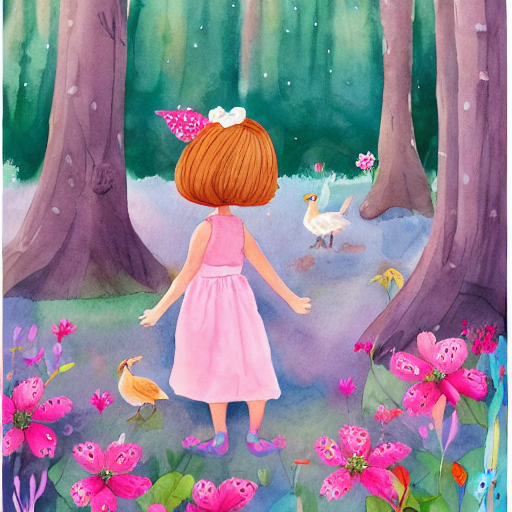

Image saved: /content/drive/MyDrive/PUSL3205_Lab03_TinyTransformer/first_story_illustration.png


In [56]:

# Step 16.19: Generate First Story Illustration

from IPython.display import display
import os
import torch

image_prompt = (
    "A little girl named Lily exploring a magical forest, "
    "friendly animals, colorful flowers, beautiful trees, "
    "children's storybook illustration, soft watercolor style, "
    "warm sunlight, detailed, charming, family friendly"
)

print("Generating AI Story Illustration...")

with torch.inference_mode():
    result = image_pipe(
        prompt=image_prompt,
        negative_prompt=(
            "blurry, distorted, low quality, scary, "
            "violent, text, watermark"
        ),
        num_inference_steps=25,
        guidance_scale=7.5,
        height=512,
        width=512
    )

story_image = result.images[0]

display(story_image)

image_path = (
    "/content/drive/MyDrive/"
    "PUSL3205_Lab03_TinyTransformer/"
    "first_story_illustration.png"
)

os.makedirs(os.path.dirname(image_path), exist_ok=True)
story_image.save(image_path)

print("Image saved:", image_path)


In [58]:

import gradio as gr
import torch
import gc

# Generate a story and matching AI illustration
def generate_story_and_image(prompt, story_length, temperature):

    if not prompt or not prompt.strip():
        raise gr.Error("Please enter a story beginning.")

    try:
        # STEP 1: Generate story with Tiny Transformer
        improved_model.to("cuda")
        improved_model.eval()

        with torch.inference_mode():
            story = generate_improved_story(
                model=improved_model,
                prompt=prompt.strip(),
                max_new_tokens=int(story_length),
                temperature=float(temperature),
                top_k=20
            )

        # STEP 2: Free GPU memory before image generation
        improved_model.to("cpu")
        gc.collect()
        torch.cuda.empty_cache()

        # STEP 3: Build an illustration prompt from the story
        story_scene = story[:300].strip()

        illustration_prompt = (
            "Children's storybook illustration of "
            + story_scene
            + ". Beautiful watercolor painting, "
              "colorful scenery, charming characters, "
              "soft sunlight, detailed fantasy artwork."
        )

        # STEP 4: Generate AI image
        with torch.inference_mode():
            result = image_pipe(
                prompt=illustration_prompt,
                negative_prompt=(
                    "blurry, distorted, scary, "
                    "watermark, text, low quality"
                ),
                num_inference_steps=20,
                guidance_scale=7.5,
                height=512,
                width=512
            )

        illustration = result.images[0]

        return story, illustration

    except Exception as e:
        raise gr.Error(f"Generation failed: {str(e)}")

    finally:
        improved_model.to("cpu")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# Build StoryVerse AI Interface
with gr.Blocks(title="StoryVerse AI") as demo:

    gr.Markdown(
        """
        # 📖✨ StoryVerse AI
        ### Tiny Transformer Story Generator + AI Illustrations

        Create a unique story and automatically generate
        an AI illustration inspired by your story.
        """
    )

    with gr.Row():

        with gr.Column():

            prompt = gr.Textbox(
                label="✍️ Story Beginning",
                value="Once upon a time",
                lines=3
            )

            story_length = gr.Slider(
                minimum=200,
                maximum=1500,
                value=500,
                step=100,
                label="📚 Story Length (New Characters)"
            )

            temperature = gr.Slider(
                minimum=0.3,
                maximum=1.2,
                value=0.7,
                step=0.1,
                label="🎨 Creativity"
            )

            generate_btn = gr.Button(
                "✨ Generate Story & Illustration",
                variant="primary"
            )

        with gr.Column():

            illustration_output = gr.Image(
                label="🖼️ AI Story Illustration",
                type="pil",
                height=400
            )

    story_output = gr.Textbox(
        label="📖 Your AI-Generated Story",
        lines=15
    )

    generate_btn.click(
        fn=generate_story_and_image,
        inputs=[prompt, story_length, temperature],
        outputs=[story_output, illustration_output]
    )

demo.queue().launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a100b9e04fd3deda9e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
